# An Experimental Comparative Analysis of Deep Learning and Multimodal Fusion Techniques for Skin Lesion Classification Using the HAM10000 Dataset.


## Project Overview

Skin cancer is one of the most common forms of cancer worldwide. Early and accurate diagnosis of skin lesions can significantly improve patient outcomes and reduce mortality rates. Dermatologists often rely on dermoscopic images along with patient metadata such as age, sex, and lesion location to make clinical decisions.

This project investigates the effectiveness of deep learning models for automated skin lesion classification using the HAM10000 dataset. Both image information and patient metadata are utilized to improve classification performance.

The study compares multiple convolutional neural network (CNN) architectures and evaluates whether combining image features with clinical metadata can improve diagnostic accuracy compared to image-only models.

---

# Research Objectives

The primary objectives of this project are:

1. Develop deep learning models for skin lesion classification using dermoscopic images.
2. Compare the performance of multiple CNN architectures on the HAM10000 dataset.
3. Investigate the contribution of patient metadata to classification performance.
4. Design and evaluate a multimodal fusion architecture that combines image and metadata information.
5. Analyze model performance on both majority and minority lesion classes.
6. Identify the most effective architecture for automated skin lesion diagnosis.

---

# Research Questions

This study aims to answer the following questions:

### Q1:
Do models designed for other domains perform well on dermoscopy images?

Compare:

ResNet18
vs
MobileNetV2
vs
EfficientNet

### Q2 :
Does multimodal fusion improve diagnosis on the HAM10000 dataset?

Compare:

Best Image Model
vs
Fusion Model

### RQ3:

Can patient metadata alone provide useful information for skin lesion classification?

### RQ4:

Does combining image features with metadata improve classification performance compared to image-only models?



---

# Dataset

## HAM10000 Dataset

The HAM10000 (Human Against Machine with 10000 Training Images) dataset contains dermoscopic images of pigmented skin lesions.

### Lesion Classes

| Label | Description                                     |
| ----- | ----------------------------------------------- |
| akiec | Actinic Keratoses and Intraepithelial Carcinoma |
| bcc   | Basal Cell Carcinoma                            |
| bkl   | Benign Keratosis-like Lesions                   |
| df    | Dermatofibroma                                  |
| mel   | Melanoma                                        |
| nv    | Melanocytic Nevi                                |
| vasc  | Vascular Lesions                                |

### Metadata Features

The following patient information is used:

* Age
* Sex
* Lesion Localization

---

# Data Preprocessing

## Image Processing

The following preprocessing techniques are applied:

* Image resizing
* Normalization
* Data augmentation
* Tensor conversion

## Metadata Processing

The following metadata preprocessing steps are performed:

### Age

* Missing values handled
* Min-Max normalization applied

### Sex

* Label encoding

### Localization

* One-Hot Encoding

---

# Experimental Pipeline

## Phase 1: Metadata-Only Model

A Metadata MLP (Multi-Layer Perceptron) is trained using:

* Age
* Sex
* Localization

Input:
Metadata Features

Output:
7 Skin Lesion Classes

Purpose:

Evaluate how much predictive information is contained in metadata alone.

---

## Phase 2: Image-Only Models

Three CNN architectures are trained and compared.

### Model 1: ResNet18

Characteristics:

* Residual Learning
* Moderate model complexity
* Strong feature extraction capability

### Model 2: MobileNetV2

Characteristics:

* Lightweight architecture
* Low computational cost
* Efficient deployment

### Model 3: EfficientNetB0

Characteristics:

* Compound scaling
* Improved parameter efficiency
* Strong generalization capability

---

# Transfer Learning Strategy

Pretrained ImageNet weights are used.

Training procedure:

1. Freeze backbone layers
2. Train classification head
3. Unfreeze selected higher layers
4. Fine-tune the network
5. Apply learning rate scheduling
6. Use early stopping

---

# Phase 3: Multimodal Fusion Learning

The best-performing image models are combined with metadata features.

Three fusion architectures are evaluated.

### Fusion Architecture 1

ResNet18 + Metadata MLP

Image Features + Metadata Features → Fusion Layer → Classifier

### Fusion Architecture 2

MobileNetV2 + Metadata MLP

Image Features + Metadata Features → Fusion Layer → Classifier

### Fusion Architecture 3

EfficientNetB0 + Metadata MLP

Image Features + Metadata Features → Fusion Layer → Classifier

---

# Fusion Architecture Design

## Image Branch

Backbone CNN:

* ResNet18 / MobileNetV2 / EfficientNetB0

Output:

Image Feature Vector

## Metadata Branch

Metadata MLP:

Input:

* Age
* Sex
* Localization

Output:

Metadata Feature Vector

## Fusion Layer

Feature Concatenation:

Fused Features = Image Features + Metadata Features

## Classification Head

Fully Connected Layers

Output:

7-Class Softmax Prediction

---

# Training Configuration

## Loss Function

* Cross Entropy Loss
* Focal Loss (Experiments)

## Optimizer

* Adam Optimizer

## Learning Rate Scheduling

* ReduceLROnPlateau

## Regularization

* Dropout
* Early Stopping

---

# Evaluation Metrics

The following metrics are used:

* Accuracy
* Precision
* Recall
* F1-Score
* Classification Report
* Confusion Matrix

---

# Model Comparison

The following models are compared:

### Metadata Only

* Metadata MLP

### Image Only

* ResNet18
* MobileNetV2
* EfficientNetB0

### Fusion Models

* ResNet18 Fusion
* MobileNetV2 Fusion
* EfficientNetB0 Fusion

---

# Expected Outcome

This study evaluates whether multimodal learning can improve skin lesion classification performance by combining visual features from dermoscopic images with patient metadata.

The final objective is to identify the most accurate and clinically useful architecture among image-only and fusion-based deep learning models.

---------------------------------------------------------------------------------------------------------------------------------------
⚠️ Important medical disclaimer “The prediction provided by the model is for research purposes only and does not constitute a medical diagnosis.” 

“The model is trained only on lesion categories and cannot explicitly detect healthy skin.”

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [93]:
# Core
import os
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Dataset / DataLoader
from torch.utils.data import Dataset, DataLoader

# Torchvision
from torchvision import transforms, models

from torchvision.models import (
    resnet18,
    ResNet18_Weights,
    mobilenet_v2,
    MobileNet_V2_Weights,
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# Scikit-learn
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# explainable ai
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

In [3]:

meta_df = pd.read_csv("HAM10000_Project/data/HAM10000_metadata.csv")



In [4]:
meta_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
meta_df.columns


Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [6]:
meta_df.count()

lesion_id       10015
image_id        10015
dx              10015
dx_type         10015
age              9958
sex             10015
localization    10015
dtype: int64

### here is some missing in age

In [7]:
meta_df.shape

(10015, 7)

In [8]:
meta_df['dx'].value_counts()  #it shows the label classes are imbalance

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [9]:
dx_mapping = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis-like lesions',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions'
}


In [10]:
meta_df.isnull().sum() # only age is missing

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

## 1. Encode Labels dx(0-6)

In [11]:
meta_df["dx"].unique()

array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

In [12]:
# Any order is fine, but consistency matters
label_mapping = {
    'akiec':0,
    'bcc':1,
    'bkl':2,
    'df':3,
    'mel':4,
    'nv':5,
    'vasc':6
}

In [13]:
#apply endoing to data frame

meta_df['label']= meta_df['dx'].map(label_mapping) 

In [14]:
# verify encoding
meta_df[['dx','label']].sample(10)

,dx,label
2220,mel,4
1547,mel,4
4578,nv,5
3109,nv,5
2436,vasc,6
1505,mel,4
7674,nv,5
6803,nv,5
4910,nv,5
2330,vasc,6


In [15]:
#checking for missing mapping

meta_df['label'].isnull().sum()

np.int64(0)

In [16]:
# confirming data distribution(Encoded) --> Imbalance
meta_df['label'].value_counts().sort_index()

label
0     327
1     514
2    1099
3     115
4    1113
5    6705
6     142
Name: count, dtype: int64

#### Analyze class imbalance (counts, ratios)


In [17]:
class_counts=meta_df['dx'].value_counts().sort_index() # sorting in index format 0 --> 6
class_counts
# Here nv dominates the dataset, mel, df, vasc etc. are minorities. So,A naive model will ignore cancer classes. 

dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64

In [18]:
# We are giving weights to each class according toimportance if a class a minor sample weight will be larger otherwise smaller

num_classes= 7
total_samples= len(meta_df)
class_weights = [] 

for i in range(num_classes):
    class_count= class_counts [i] # No. of samples per class
    weight= total_samples / ( num_classes *  class_count) 
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

/tmp/ipykernel_6518/3725825812.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_count= class_counts [i] # No. of samples per class


tensor([ 4.3753,  2.7835,  1.3018, 12.4410,  1.2855,  0.2134, 10.0755])

## Defining Focal Loss and Criterion

In [19]:

# Step 1 — smooth your existing class_weights
smoothed = np.sqrt(class_weights.numpy())
smoothed = torch.tensor(smoothed / smoothed.sum() * num_classes, dtype=torch.float)

# Step 2 — define Focal Loss using smoothed weights
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets,
                                  weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Step 3 — instantiate it
# ── Step 2: build FocalLoss using smoothed weights ──
criterion = FocalLoss(alpha=smoothed.to(device), gamma=3.0)
#           ↑ this is what gets passed into train_one_epoch

In [20]:
criterion

FocalLoss()

In [21]:
print( "Class_counts",class_counts, " Weights",class_weights)

Class_counts dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64  Weights tensor([ 4.3753,  2.7835,  1.3018, 12.4410,  1.2855,  0.2134, 10.0755])


#### Handle imbalance (loss weights / sampling)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device) 

In [23]:
class_weights

tensor([ 4.3753,  2.7835,  1.3018, 12.4410,  1.2855,  0.2134, 10.0755],
       device='cuda:0')

In [24]:
# Plug class weights into a Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion

CrossEntropyLoss()

## 2. Enocde metadata(sex,loaclization)

In [25]:
meta_df.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,2
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,2
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face,2
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,2
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,2


In [26]:
meta_df['dx_type'].unique()

array(['histo', 'consensus', 'confocal', 'follow_up'], dtype=object)

In [27]:
meta_df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label            0
dtype: int64

#### Sex Encoding

In [28]:
meta_df['sex'].unique()

array(['male', 'female', 'unknown'], dtype=object)

In [29]:
sex_mapping= {
    'male': 1,
    'female': 0,
    'unknown':-1
}

In [30]:
meta_df['sex_encoded'] = meta_df['sex'].map(sex_mapping)

In [31]:
meta_df[['sex', 'sex_encoded']].value_counts()


sex      sex_encoded
male      1             5406
female    0             4552
unknown  -1               57
Name: count, dtype: int64

In [32]:
meta_df['sex_encoded'].isnull().sum()


np.int64(0)

#### Encoding Localization

In [33]:
meta_df['localization'].unique()

array(['scalp', 'ear', 'face', 'back', 'trunk', 'chest',
       'upper extremity', 'abdomen', 'unknown', 'lower extremity',
       'genital', 'neck', 'hand', 'foot', 'acral'], dtype=object)

In [34]:
meta_df['localization'].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

In [35]:
# ==========================================
# One-Hot Encoding For Localization
# ==========================================

localization_dummies = pd.get_dummies(

    meta_df['localization'],

    prefix='loc'
).astype(int)

# Add one-hot columns into dataframe

meta_df = pd.concat(

    [meta_df, localization_dummies],

    axis=1
)

# Save localization feature column names

localization_feature_columns = localization_dummies.columns.tolist()

print(localization_feature_columns)

['loc_abdomen', 'loc_acral', 'loc_back', 'loc_chest', 'loc_ear', 'loc_face', 'loc_foot', 'loc_genital', 'loc_hand', 'loc_lower extremity', 'loc_neck', 'loc_scalp', 'loc_trunk', 'loc_unknown', 'loc_upper extremity']


In [36]:
meta_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label,sex_encoded,loc_abdomen,...,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2,1,0,...,0,0,0,0,0,0,1,0,0,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2,1,0,...,0,0,0,0,0,0,1,0,0,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2,1,0,...,0,0,0,0,0,0,1,0,0,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2,1,0,...,0,0,0,0,0,0,1,0,0,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2,1,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
meta_df.drop(columns=['localization'] , inplace= True)

## 3. Normalize age

In [38]:
meta_df['age'].describe()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

In [39]:
median_age= meta_df['age'].median() 
meta_df['age_filled'] = meta_df['age'].fillna(median_age)

In [40]:
#Normalize age using Z-score normaliztion
age_mean = meta_df['age_filled'].mean()
age_std = meta_df['age_filled'].std()

meta_df['age_normalized'] = (meta_df['age_filled'] - age_mean) / age_std

In [41]:
print(age_mean)

51.853220169745384


In [42]:
print(age_std)

16.92083280896139


In [43]:
meta_df['age_normalized'].describe()

count    1.001500e+04
mean    -1.589232e-16
std      1.000000e+00
min     -3.064460e+00
25%     -7.005104e-01
50%     -1.095230e-01
75%      7.769582e-01
max      1.958933e+00
Name: age_normalized, dtype: float64

In [44]:
meta_df.isnull().sum()

lesion_id               0
image_id                0
dx                      0
dx_type                 0
age                    57
sex                     0
label                   0
sex_encoded             0
loc_abdomen             0
loc_acral               0
loc_back                0
loc_chest               0
loc_ear                 0
loc_face                0
loc_foot                0
loc_genital             0
loc_hand                0
loc_lower extremity     0
loc_neck                0
loc_scalp               0
loc_trunk               0
loc_unknown             0
loc_upper extremity     0
age_filled              0
age_normalized          0
dtype: int64

In [45]:
# Select Final Model Columns
model_df = meta_df[['image_id','sex_encoded','age_normalized','label'] + localization_feature_columns].copy()

In [46]:
model_df.head(5)

,image_id,sex_encoded,age_normalized,label,loc_abdomen,loc_acral,loc_back,loc_chest,loc_ear,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
0,ISIC_0027419,1,1.663439,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,ISIC_0025030,1,1.663439,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,ISIC_0026769,1,1.663439,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,ISIC_0025661,1,1.663439,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,ISIC_0031633,1,1.367946,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [47]:
model_df.isnull().sum()

image_id               0
sex_encoded            0
age_normalized         0
label                  0
loc_abdomen            0
loc_acral              0
loc_back               0
loc_chest              0
loc_ear                0
loc_face               0
loc_foot               0
loc_genital            0
loc_hand               0
loc_lower extremity    0
loc_neck               0
loc_scalp              0
loc_trunk              0
loc_unknown            0
loc_upper extremity    0
dtype: int64

## images data pipelining validation

In [48]:
image_dir = "HAM10000_Project/data/HAM10000_images"

In [49]:
model_df.iloc[0]["image_id"] # showing output

'ISIC_0027419'

In [50]:
sample_id = model_df.iloc[1]["image_id"]

In [51]:
os.path.join(image_dir, sample_id) 

'HAM10000_Project/data/HAM10000_images/ISIC_0025030'

In [52]:
img_path= os.path.join(image_dir, sample_id + ".jpg")  # joining path

In [53]:
img_path

'HAM10000_Project/data/HAM10000_images/ISIC_0025030.jpg'

In [54]:
img=Image.open(img_path)

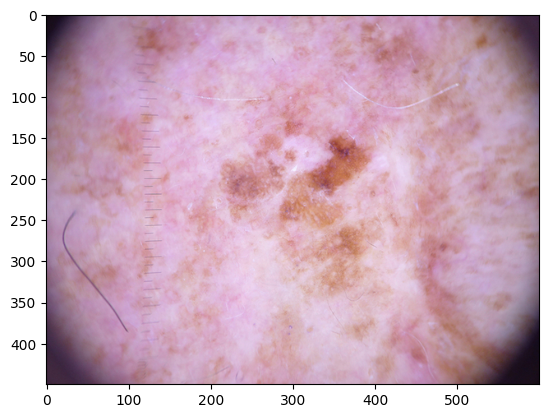

In [55]:
plt.imshow(img)
#plt.axis("off")

## 4. Building first pytorch dataset class

### Data Augemntation - Standard for majority and aggressive for minority

In [56]:
#Data Augemtation for training only

# ── Training: Majority classes (nv, mel, bkl) ──
standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Training: Minority classes (akiec, bcc, df, vasc) ──
minority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Val and Test — no augmentation ──
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [57]:
MINORITY_INDICES = {0, 1, 3, 6}  # akiec, bcc, df, vasc

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, minority_transform=None, minority_indices=None):
        
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.minority_transform = minority_transform
        self.minority_indices = minority_indices or set()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # ---- 1. Load image ----
        image_id = self.df.loc[idx, 'image_id']
        image_path = os.path.join(self.image_dir, image_id + ".jpg")
        image = Image.open(image_path).convert("RGB")

        # ---- 2. Read label first, then pick transform ----
        label = self.df.loc[idx, 'label']

        if self.minority_transform and label in self.minority_indices:
            image = self.minority_transform(image)  # akiec, bcc, df, vasc
        elif self.transform:
            image = self.transform(image)           # nv, mel, bkl

        # ---- 3. Load metadata ----
        localization_features = self.df.loc[
            idx, localization_feature_columns].values.astype('float32')
        metadata = torch.tensor([
                self.df.loc[idx, 'age_normalized'],
                self.df.loc[idx, 'sex_encoded'],
                *localization_features],
            dtype=torch.float32)

        # ---- 4. Load label ----
        label = torch.tensor(label, dtype=torch.long)
        return image, metadata, label

#### Train , val split

In [58]:
# Training = 80% , val = 10%, Test=10% 

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42,
    stratify=model_df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)


In [59]:
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nClass distribution across splits:")

label_names = {0:'akiec', 1:'bcc', 2:'bkl', 3:'df', 4:'mel', 5:'nv', 6:'vasc'}

for label_idx in range(7):
    train_count = (train_df['label'] == label_idx).sum()
    val_count   = (val_df['label']   == label_idx).sum()
    test_count  = (test_df['label']  == label_idx).sum()
    total       = train_count + val_count + test_count
    print(f"{label_names[label_idx]:6} | "
          f"Train: {train_count:4} ({train_count/total*100:.0f}%) | "
          f"Val: {val_count:3} ({val_count/total*100:.0f}%) | "
          f"Test: {test_count:3} ({test_count/total*100:.0f}%)")

Train: 8012 | Val: 1001 | Test: 1002

Class distribution across splits:
akiec  | Train:  262 (80%) | Val:  33 (10%) | Test:  32 (10%)
bcc    | Train:  411 (80%) | Val:  51 (10%) | Test:  52 (10%)
bkl    | Train:  879 (80%) | Val: 110 (10%) | Test: 110 (10%)
df     | Train:   92 (80%) | Val:  12 (10%) | Test:  11 (10%)
mel    | Train:  890 (80%) | Val: 111 (10%) | Test: 112 (10%)
nv     | Train: 5364 (80%) | Val: 670 (10%) | Test: 671 (10%)
vasc   | Train:  114 (80%) | Val:  14 (10%) | Test:  14 (10%)


In [60]:
#checking class imbalance
train_df['label'].value_counts(normalize=True)
val_df['label'].value_counts(normalize=True)


label
5    0.669331
4    0.110889
2    0.109890
1    0.050949
0    0.032967
6    0.013986
3    0.011988
Name: proportion, dtype: float64

In [61]:
# Reset Index (IMPORTANT), This avoids silent bugs inside Dataset.__getitem__.
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


# 5. Define image transforms

#### — Create Separate Datasets (Train vs Val)

In [62]:
image_dir = "HAM10000_Project/data/HAM10000_images"

# ── Training set ──
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    image_dir=image_dir,
    transform=standard_transform,
    minority_transform=minority_transform,
    minority_indices=MINORITY_INDICES
)

# ── Validation set ──
val_dataset = HAM10000Dataset(
    dataframe=val_df,
    image_dir=image_dir,
    transform=val_test_transform
)

# ── Test set ──
test_dataset = HAM10000Dataset(
    dataframe=test_df,
    image_dir=image_dir,
    transform=val_test_transform
)

In [63]:
#checking
img_train, _, _ = train_dataset[0]
img_val, _, _ = val_dataset[0]

print(img_train.shape, img_val.shape)



torch.Size([3, 224, 224]) torch.Size([3, 224, 224])


# 7: DataLoader

In [64]:
batch_size= 32

## These dataloaders are for image Architectures only

In [65]:
#train loader
train_loader= DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # true for training
    num_workers=2,  # multi-process loading
    pin_memory=True
)


#validation Loader
val_loader = DataLoader(
    val_dataset,
    batch_size= batch_size,
    shuffle= False, # Flase for validation
    num_workers=2, # multi-process loading
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [66]:
# Test one batch

images, metadata, labels = next(iter(train_loader))
print("images:", images.shape)
print("metadata:", metadata.shape)
print("labels:", labels.shape)

images: torch.Size([32, 3, 224, 224])
metadata: torch.Size([32, 17])
labels: torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8721637].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

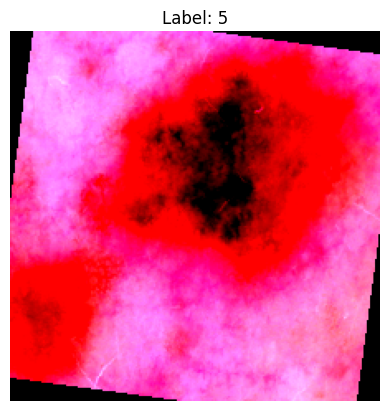

In [67]:
# Visulize a batch image

plt.imshow(images[0].permute(1, 2, 0))
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")


# (A). Metadata-only MLP

#### seeding for deterministic results

In [68]:
def set_seed(seed=42):
    random.seed(seed) #Locks randomness for basic Python lists and NumPy arrays (used for data processing).
    np.random.seed(seed) #do the same as above
    torch.manual_seed(seed) # Locks randomness for PyTorch tensors and weight initialization.
    torch.cuda.manual_seed(seed) 
    torch.cuda.manual_seed_all(seed) #Ensures that if you are using one or more GPUs, they all use the same starting point for their random numbers.

    # Make CUDA deterministic
    torch.backends.cudnn.deterministic = True #Forces the GPU to use only "predictable" algorithms. Some high-speed GPU tricks produce slightly different results each time; this turns them off.
    torch.backends.cudnn.benchmark = False #  Prevents the GPU from searching for the fastest way to run your specific configuration, which can introduce tiny variations in calculations.

set_seed(42)



In [69]:
# So now we must split model_df,
train_df, val_df = train_test_split(
    model_df,
    test_size=0.15,
    random_state=42,
    stratify=model_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)


#### we must make sure the loaders are rebuilt from these new train_df, val_df , not using the images loader

In [70]:
class HAMMetaDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Localization one-hot features
        localization_features = self.df.loc[
            idx,
            localization_feature_columns
        ].values.astype('float32')

        # Full metadata vector
        metadata = torch.tensor(
            [
                self.df.loc[idx, 'age_normalized'],
                self.df.loc[idx, 'sex_encoded'],
                *localization_features
            ],
            dtype=torch.float32
        )


        label = torch.tensor(
            self.df.loc[idx, 'label'],
            dtype=torch.long
        )


        return metadata, label

In [71]:
meta_train_dataset = HAMMetaDataset(train_df)
meta_val_dataset   = HAMMetaDataset(val_df)

#loaders for meta data only
meta_train_loader = DataLoader(meta_train_dataset, batch_size=32, shuffle=True)
meta_val_loader   = DataLoader(meta_val_dataset, batch_size=32, shuffle=False)



In [72]:
#define metadata MLP
class MetaNet(nn.Module):
    def __init__(self,input_dim,num_classes=7):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )


    def forward(self, x):
        return self.net(x)



In [73]:
# initial Model and Move to GPU
meta_input_dim = 2 + len(localization_feature_columns)

meta_model = MetaNet(meta_input_dim, num_classes=7).to(device)
meta_model

MetaNet(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=7, bias=True)
  )
)

In [74]:

# loss function for metadata-only model
criterion_meta = FocalLoss(alpha=smoothed.to(device), gamma=2.0)  # same criterion

# optimizer for metadata-only model
optimizer_meta = torch.optim.Adam(
    meta_model.parameters(),
    lr=1e-4
)


In [164]:
#training loop(meta_only)

def train_one_epoch_meta(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    # Initialize accuracy counter
    correct = 0
    
    for metadata, labels in loader:
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(metadata)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * metadata.size(0)
        
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()



    epoch_loss = running_loss / len(loader.dataset)

    accuracy = correct / len(loader.dataset)

    return epoch_loss, accuracy


In [165]:
#validation Loop(metadata only)         

def validate_one_epoch_meta(model, loader, device):  
    model.eval()
    running_loss = 0.0
    correct = 0
    with torch.no_grad():
        for metadata, labels in loader:
            metadata = metadata.to(device)
            labels = labels.to(device)
            outputs = model(metadata)
            loss = F.cross_entropy(outputs, labels)  # ← plain CE, no weights
            running_loss += loss.item() * metadata.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return epoch_loss, accuracy

In [166]:
num_epochs = 15

best_val_loss = float("inf")

patience = 3

epochs_without_improvement = 0


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_meta,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)


for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch_meta(
        meta_model,
        meta_train_loader,
        criterion_meta,
        optimizer_meta,
        device
    )

    val_loss, val_acc = validate_one_epoch_meta(
        meta_model,
        meta_val_loader,
        device
    )

    scheduler.step(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            meta_model.state_dict(),
            "metadata_only_model.pth"
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    current_lr = optimizer_meta.param_groups[0]['lr']

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if epochs_without_improvement >= patience:

        print("Early stopping triggered.")

        break

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/15] | Train Loss: 0.3628 | Train Acc: 0.1366 | Val Loss: 1.8945 | Val Acc: 0.3726 | LR: 0.000100
Epoch [2/15] | Train Loss: 0.3528 | Train Acc: 0.4537 | Val Loss: 1.8152 | Val Acc: 0.5063 | LR: 0.000100
Epoch [3/15] | Train Loss: 0.3423 | Train Acc: 0.5363 | Val Loss: 1.7375 | Val Acc: 0.5496 | LR: 0.000100
Epoch [4/15] | Train Loss: 0.3317 | Train Acc: 0.5281 | Val Loss: 1.6759 | Val Acc: 0.5509 | LR: 0.000100
Epoch [5/15] | Train Loss: 0.3229 | Train Acc: 0.5305 | Val Loss: 1.6435 | Val Acc: 0.5329 | LR: 0.000100
Epoch [6/15] | Train Loss: 0.3147 | Train Acc: 0.5267 | Val Loss: 1.6128 | Val Acc: 0.5462 | LR: 0.000100
Epoch [7/15] | Train Loss: 0.3096 | Train Acc: 0.5425 | Val Loss: 1.5904 | Val Acc: 0.5429 | LR: 0.000100
Epoch [8/15] | Train Loss: 0.3062 | Train Acc: 0.5369 | Val Loss: 1.5911 | Val Acc: 0.5522 | LR: 0.000100
Epoch [9/15] | Train Loss: 0.3018 | Train Acc: 0.5418 | Val Loss: 1.5761 | Val Acc: 0.5549 | LR: 0.000100
Epoch [10/15] | Train Loss: 0.2993 | Train Acc

In [167]:
# evaluate metaonly
meta_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for metadata, labels in meta_val_loader:
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = meta_model(metadata)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


In [168]:
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


              precision    recall  f1-score   support

       akiec     0.1982    0.4490    0.2750        49
         bcc     0.1474    0.3636    0.2097        77
         bkl     0.2391    0.1333    0.1712       165
          df     0.0391    0.4118    0.0714        17
         mel     0.1700    0.3054    0.2184       167
          nv     0.8811    0.5527    0.6793      1006
        vasc     0.0000    0.0000    0.0000        22

    accuracy                         0.4564      1503
   macro avg     0.2393    0.3165    0.2322      1503
weighted avg     0.6494    0.4564    0.5183      1503



/home/wasidkhan/torch-venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wasidkhan/torch-venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wasidkhan/torch-venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

### Meta MLP Results with OHE enconding for Localization column

### Meta MLP Results with integer enconding for Localization column 

# (B). Image-only CNN (baseline)


#### Final Experiment Design 

## Image-Model 2. ResNet18 Architecture

### step1️ Load pretrained ResNet18


In [169]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [170]:
#Load pretrained resnet18 model

resnet18 = models.resnet18(pretrained= True) 


/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [171]:
print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### step2️ Replace final classification layer (7 classes)


In [172]:
num_classes = 7
#replacing the final layers with our 7 classes classification
in_features = resnet18.fc.in_features

resnet18.fc = nn.Linear(in_features,num_classes) # replacing fullyconnected layer with 7 classes

In [173]:
resnet18.fc

Linear(in_features=512, out_features=7, bias=True)

In [174]:
resnet18= resnet18.to(device) #model moved to GPU

In [175]:
# Sanity Check (Forward Pass, NO TRAINING) ,We test one batch from our train_loader.

images, _, labels = next(iter(train_loader)) 

images = images.to(device)
labels = labels.to(device) 

outputs=resnet18(images)
print("Output shape:", outputs)  # 32 rows, 7 columns

Output shape: tensor([[ 0.7545,  0.9299, -0.0425,  1.2674,  0.0752,  0.8170, -0.3204],
        [ 0.8386,  0.7828, -0.0999,  0.7175,  0.1685,  0.3178, -0.7783],
        [ 0.1016,  0.9744, -0.7353,  0.4495, -0.6116,  0.1032, -0.8239],
        [ 0.0752,  0.8462, -1.4995,  1.0461, -0.1914,  0.5626, -0.0124],
        [ 0.1636,  0.8732,  0.0251,  0.3896, -0.3020,  0.6064, -0.3664],
        [ 1.0524,  0.1465, -0.3037,  1.0376,  0.0146,  0.1132,  0.2478],
        [ 0.0496, -0.0884, -0.3829,  0.5286, -0.0818,  0.0437, -0.1145],
        [ 0.8173,  0.7362, -0.2702,  1.1157, -0.3075,  0.1980,  0.0351],
        [ 0.5235,  0.2925, -0.6457,  0.0827, -0.6020,  0.2540, -0.6243],
        [ 0.1886,  0.8569, -0.7704,  0.2138, -0.0269,  0.8594, -0.3355],
        [ 1.0214,  0.1945, -0.0378,  1.1914, -0.2608,  0.2682,  0.4533],
        [ 0.7060,  1.1731, -0.5685,  1.0489,  0.1402,  0.8522, -0.3535],
        [ 0.5767,  1.1891,  0.0310,  1.2690, -0.9019,  0.5930,  0.3953],
        [-0.1575,  0.5618, -0.6212,  

### step 3 Freeze early layers (initially)


In [176]:
# Freeze everything except fc, Train only the final layer ( we will unfreeze deep layers later)

for param in resnet18.parameters():
    param.requires_grad = False


In [177]:
#unfreeze the final fc layer

for param in resnet18.fc.parameters():
    param.requires_grad= True


In [178]:
#verify whats trainable

trainable_param = [
    name for name, param in resnet18.named_parameters()
    if param.requires_grad
]

In [179]:
trainable_param

['fc.weight', 'fc.bias']

### step 4 Define loss function & optimizer

In [181]:
#check optimizer parameters
list(optimizer.param_groups[0]['params'])


[Parameter containing:
 tensor([[-0.0408, -0.0183, -0.0232,  ..., -0.0290,  0.0106,  0.0044],
         [-0.0235,  0.0108, -0.0167,  ...,  0.0155, -0.0401,  0.0168],
         [ 0.0178, -0.0241,  0.0087,  ..., -0.0177, -0.0072,  0.0068],
         ...,
         [ 0.0174,  0.0122,  0.0134,  ...,  0.0409,  0.0172, -0.0402],
         [ 0.0020, -0.0378,  0.0329,  ...,  0.0410, -0.0045, -0.0382],
         [ 0.0254,  0.0176, -0.0256,  ...,  0.0129, -0.0006, -0.0188]],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([ 0.0289, -0.0216,  0.0350, -0.0266,  0.0386,  0.0381,  0.0048],
        device='cuda:0', requires_grad=True)]

In [182]:
len(list(optimizer.param_groups[0]['params'])) # fc.weight and fc.bias

2

### step 5 Train image-only model


##### Training loop image only

In [183]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0

    for images, _, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)

    return epoch_loss, accuracy


##### Validation Loop

In [184]:
def validate_one_epoch(model, loader, device):  
    model.eval()
    running_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, _, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)  # ← plain CE, no weights
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return epoch_loss, accuracy

##### Full Training Loop

#### Unfreeze ResNet18 Backbone

In [111]:
# Unfreeze ResNet18 backbone  ( This allows the entire network to update.)
for param in resnet18.parameters():
    param.requires_grad = True

#### New Optimizer for Fine-Tuning

Use a smaller learning rate for fine-tuning.

In [112]:
optimizer = optim.Adam(
    resnet18.parameters(),
    lr=1e-4
)

In [113]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='min',          # monitor validation loss

    factor=0.5,          # reduce LR by half

    patience=2,          # wait 2 epochs

    verbose=True
)

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


#### ResNet18 Fine-Tuning Loop

In [114]:
best_val_loss = float("inf")

fine_tune_epochs = 50

# Early stopping patience
patience = 5

# Counter for consecutive non-improving epochs
epochs_without_improvement = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(fine_tune_epochs):


    # Training

    train_loss, train_acc = train_one_epoch(
        resnet18,
        train_loader,
        criterion,
        optimizer,
        device
    )


    # Validation
    val_loss, val_acc = validate_one_epoch(
        resnet18,
        val_loader,
        device )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # LR schedular
    scheduler.step(val_loss)

    # Save Best Model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            resnet18.state_dict(),
            "resnet18_finetuned.pth" 
        )

        # Reset counter
        epochs_without_improvement = 0
        print("✔ Best model saved.")

    else:

        # Increase counter
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )


    # Print Metrics


    print(

        f"FineTune Epoch [{epoch+1}/{fine_tune_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}" )

  
    # Early Stopping

    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping triggered after "
            f"{patience} epochs without improvement."
        )

        break

✔ Best model saved.
FineTune Epoch [1/50] | Train Loss: 1.0474 | Train Acc: 0.6323 | Val Loss: 0.7895 | Val Acc: 0.7083
✔ Best model saved.
FineTune Epoch [2/50] | Train Loss: 0.7152 | Train Acc: 0.7164 | Val Loss: 0.7498 | Val Acc: 0.7253
✔ Best model saved.
FineTune Epoch [3/50] | Train Loss: 0.6147 | Train Acc: 0.7473 | Val Loss: 0.6464 | Val Acc: 0.7602
No improvement for 1 epoch(s).
FineTune Epoch [4/50] | Train Loss: 0.5497 | Train Acc: 0.7751 | Val Loss: 0.6639 | Val Acc: 0.7393
✔ Best model saved.
FineTune Epoch [5/50] | Train Loss: 0.4853 | Train Acc: 0.7857 | Val Loss: 0.5840 | Val Acc: 0.7852
No improvement for 1 epoch(s).
FineTune Epoch [6/50] | Train Loss: 0.4750 | Train Acc: 0.8019 | Val Loss: 0.6666 | Val Acc: 0.7273
No improvement for 2 epoch(s).
FineTune Epoch [7/50] | Train Loss: 0.4458 | Train Acc: 0.8045 | Val Loss: 0.6954 | Val Acc: 0.7562
✔ Best model saved.
FineTune Epoch [8/50] | Train Loss: 0.4040 | Train Acc: 0.8226 | Val Loss: 0.5690 | Val Acc: 0.7922
No impr

###  Evaluate (F1, recall, confusion matrix)


In [115]:
import numpy as np

resnet18.eval()

y_true_resnet_image = []
y_pred_resnet_image = []

all_preds_resnet_image = []
all_labels_resnet_image = []

with torch.no_grad():
    for images, _, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18(images)
        preds = torch.argmax(outputs, dim=1)

        y_true_resnet_image.extend(
            labels.cpu().numpy())

        y_pred_resnet_image.extend(
            preds.cpu().numpy())

        all_preds_resnet_image.append(
            preds.cpu().numpy())

        all_labels_resnet_image.append(
            labels.cpu().numpy())

all_preds_resnet_image = np.concatenate(
    all_preds_resnet_image)

all_labels_resnet_image = np.concatenate(
    all_labels_resnet_image)

print(
    "Total samples evaluated:",
    len(all_labels_resnet_image)
)

class_names = [
    'akiec',
    'bcc',
    'bkl',
    'df',
    'mel',
    'nv',
    'vasc'
]

print(
    classification_report(
        all_labels_resnet_image,
        all_preds_resnet_image,
        target_names=class_names,
        digits=4
    )
)

Total samples evaluated: 1001
              precision    recall  f1-score   support

       akiec     0.7778    0.8485    0.8116        33
         bcc     0.8182    0.8824    0.8491        51
         bkl     0.7788    0.8000    0.7892       110
          df     0.8333    0.8333    0.8333        12
         mel     0.6774    0.7568    0.7149       111
          nv     0.9568    0.9254    0.9408       670
        vasc     0.9231    0.8571    0.8889        14

    accuracy                         0.8861      1001
   macro avg     0.8236    0.8433    0.8325      1001
weighted avg     0.8913    0.8861    0.8882      1001



### RESNET18 TEST EVALUATION

In [116]:
# Load resnet18 best model
resnet18.load_state_dict(

    torch.load(

        "resnet18_finetuned.pth",

        weights_only=True
    )
)

<All keys matched successfully>

In [117]:
resnet18.eval()
all_preds = []
all_labels = []


with torch.no_grad():
    
    for images, metadata, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = resnet18(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(
            preds.cpu().numpy() )

        all_labels.extend(
            labels.cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    ))

              precision    recall  f1-score   support

       akiec     0.6154    0.7500    0.6761        32
         bcc     0.8039    0.7885    0.7961        52
         bkl     0.7685    0.7545    0.7615       110
          df     0.8889    0.7273    0.8000        11
         mel     0.7248    0.7054    0.7149       112
          nv     0.9435    0.9449    0.9442       671
        vasc     0.9286    0.9286    0.9286        14

    accuracy                         0.8802      1002
   macro avg     0.8105    0.7999    0.8030      1002
weighted avg     0.8813    0.8802    0.8804      1002



In [118]:
# useful for plots
resnet_history = {

    "train_loss": train_losses,

    "val_loss": val_losses,

    "train_acc": train_accuracies,

    "val_acc": val_accuracies
}

In [119]:
cm = confusion_matrix(all_labels, all_preds)
cm


array([[ 24,   2,   2,   0,   1,   3,   0],
       [  2,  41,   3,   0,   3,   3,   0],
       [  9,   2,  83,   0,   3,  13,   0],
       [  0,   1,   0,   8,   1,   1,   0],
       [  4,   0,  10,   1,  79,  18,   0],
       [  0,   5,  10,   0,  21, 634,   1],
       [  0,   0,   0,   0,   1,   0,  13]])

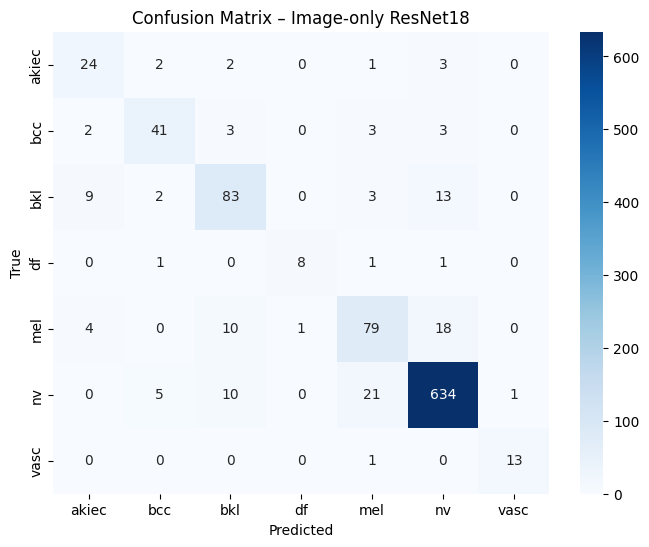

In [120]:

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Image-only ResNet18")
plt.savefig(
    "resnet18_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [121]:
# Melanoma recall

from sklearn.metrics import recall_score
mel_class_index = class_names.index('mel')
mel_recall = recall_score(
    all_labels,
    all_preds,
    labels=[mel_class_index],
    average='macro'
)
print(f"Melanoma Recall: {mel_recall:.4f}")


Melanoma Recall: 0.7054


## ImageModel 2. MobileNetv2 Architecture (IoT / Edge Vision Model)

#### Important Rule for These New Models (MobileNet and EfficientNet)
##### Use exactly the same pipeline as ResNet18:

#### Load Pretrained Model MobileV2

In [123]:
# Load pretrained MobileNetV2
weights = MobileNet_V2_Weights.DEFAULT
mobilenet_model = mobilenet_v2(weights=weights)

# Replace classifier for 7 classes
in_features = mobilenet_model.classifier[1].in_features
mobilenet_model.classifier[1] = nn.Linear(in_features, 7)

mobilenet_model = mobilenet_model.to(device)

mobilenet_model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

#### Freeze Backbone (Same Strategy as ResNet)

In [124]:
# Freeze feature extractor
for param in mobilenet_model.features.parameters():
    param.requires_grad = False

#### Train Classifier (Frozen Backbone)

#### Fine-Tune the Backbone

Now we unfreeze the network, exactly like our ResNet section.

In [125]:
# Unfreeze the backbone for fine-tuning
for param in mobilenet_model.features.parameters():
    param.requires_grad = True

#### New Optimizer for Fine-Tuning

In [126]:
optimizer = optim.Adam(
    mobilenet_model.parameters(),
    lr=1e-4
)

#### Fine-Tune Training

In [127]:

best_val_loss = float("inf")
fine_tune_epochs = 50

patience = 5
epochs_without_improvement = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(fine_tune_epochs):
    # training
    train_loss, train_acc = train_one_epoch(
        mobilenet_model,
        train_loader,
        criterion,
        optimizer,
        device )

    #val
    val_loss, val_acc = validate_one_epoch(
        mobilenet_model,
        val_loader,
        device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    
    # Scheduler Step
    scheduler.step(val_loss)

    # Save Best Model

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            mobilenet_model.state_dict(),
            "mobilenetv2_finetuned.pth" )

        # Reset counter
        epochs_without_improvement = 0
        print("✔ Best model saved.")
    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    current_lr = optimizer.param_groups[0]['lr']

    # Print Metrics
    print(

        f"FineTune Epoch [{epoch+1}/{fine_tune_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )


    # Early Stopping

    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping triggered after "
            f"{patience} epochs without improvement."
        )

        break
        

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✔ Best model saved.
FineTune Epoch [1/50] | Train Loss: 1.3186 | Train Acc: 0.5975 | Val Loss: 0.8692 | Val Acc: 0.7043 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [2/50] | Train Loss: 0.8072 | Train Acc: 0.7106 | Val Loss: 0.7137 | Val Acc: 0.7283 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [3/50] | Train Loss: 0.6507 | Train Acc: 0.7529 | Val Loss: 0.6709 | Val Acc: 0.7413 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [4/50] | Train Loss: 0.5673 | Train Acc: 0.7586 | Val Loss: 0.5932 | Val Acc: 0.7772 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [5/50] | Train Loss: 0.4942 | Train Acc: 0.7833 | Val Loss: 0.5591 | Val Acc: 0.7742 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [6/50] | Train Loss: 0.4530 | Train Acc: 0.8060 | Val Loss: 0.4935 | Val Acc: 0.8102 | LR: 0.000100
No improvement for 1 epoch(s).
FineTune Epoch [7/50] | Train Loss: 0.4286 | Train Acc: 0.8148 | Val Loss: 0.5178 | Val Acc: 0.7932 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [8/50] | 

In [128]:
# usefyl for plot
mobilenet_history = {

    "train_loss": train_losses,

    "val_loss": val_losses,

    "train_acc": train_accuracies,

    "val_acc": val_accuracies
}

#### Evaluation (Same as ResNet)

In [129]:

mobilenet_model.eval()

y_true_mobile_image = []
y_pred_mobile_image = []

all_preds_mobile_image = []
all_labels_mobile_image = []

with torch.no_grad():
    for images, _, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mobilenet_model(images)

        preds = torch.argmax(outputs, dim=1)

        y_true_mobile_image.extend(
            labels.cpu().numpy()
        )

        y_pred_mobile_image.extend(
            preds.cpu().numpy()
        )

        all_preds_mobile_image.append(
            preds.cpu().numpy()
        )

        all_labels_mobile_image.append(
            labels.cpu().numpy()
        )

all_preds_mobile_image = np.concatenate(
    all_preds_mobile_image
)

all_labels_mobile_image = np.concatenate(
    all_labels_mobile_image
)

print(
    "Total samples evaluated:",
    len(all_labels_mobile_image)
)

class_names = [
    'akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'
]

print(
    classification_report(
        all_labels_mobile_image,
        all_preds_mobile_image,
        target_names=class_names,
        digits=4
    )
)

Total samples evaluated: 1001
              precision    recall  f1-score   support

       akiec     0.7647    0.7879    0.7761        33
         bcc     0.8723    0.8039    0.8367        51
         bkl     0.8019    0.7727    0.7870       110
          df     0.6471    0.9167    0.7586        12
         mel     0.7404    0.6937    0.7163       111
          nv     0.9266    0.9418    0.9341       670
        vasc     1.0000    0.8571    0.9231        14

    accuracy                         0.8821      1001
   macro avg     0.8219    0.8248    0.8189      1001
weighted avg     0.8818    0.8821    0.8814      1001



## MOBILENET TEST EVALUATION

In [130]:
mobilenet_model.load_state_dict(

    torch.load(

        "mobilenetv2_finetuned.pth",

        weights_only=True
    )
)

<All keys matched successfully>

In [131]:
mobilenet_model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [132]:
all_preds = []
all_labels = []


with torch.no_grad():

    for images, metadata, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)


        outputs = mobilenet_model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )
        all_labels.extend(
            labels.cpu().numpy()
        )


print(

    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       akiec     0.5946    0.6875    0.6377        32
         bcc     0.9184    0.8654    0.8911        52
         bkl     0.8438    0.7364    0.7864       110
          df     0.8182    0.8182    0.8182        11
         mel     0.6250    0.7143    0.6667       112
          nv     0.9429    0.9344    0.9386       671
        vasc     0.8125    0.9286    0.8667        14

    accuracy                         0.8752      1002
   macro avg     0.7936    0.8121    0.8008      1002
weighted avg     0.8809    0.8752    0.8771      1002



In [133]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(all_labels, all_preds))


Confusion Matrix:

[[ 22   1   2   1   3   3   0]
 [  2  45   2   0   1   2   0]
 [  9   2  81   0   7  11   0]
 [  0   0   0   9   2   0   0]
 [  3   0   7   0  80  22   0]
 [  1   1   4   1  34 627   3]
 [  0   0   0   0   1   0  13]]


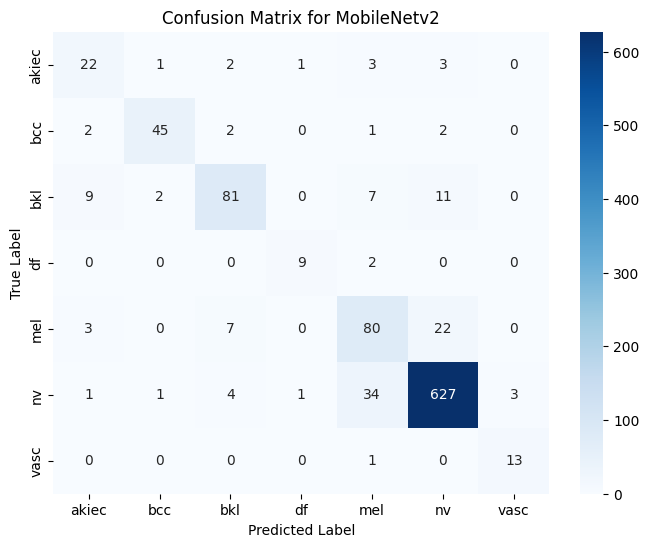

In [134]:
# Confusion matrix
cm_mobnet = confusion_matrix(all_labels, all_preds)
class_names = [
    'akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'
]
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_mobnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
     yticklabels=class_names
    )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for MobileNetv2")
plt.savefig(
    "MobileNetv2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Image Model 3. EfficientNetB0 


In [135]:
# import efficientnet

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights 

#### Load Pretrained EfficientNetB0

In [136]:
weights = EfficientNet_B0_Weights.DEFAULT
efficientnet_model = efficientnet_b0(weights=weights)

# Replace classifier for 7 classes
in_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(in_features, 7)

efficientnet_model = efficientnet_model.to(device)

efficientnet_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### Freeze Backbone

In [137]:
for param in efficientnet_model.features.parameters():
    param.requires_grad = False

In [138]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

#### Train Classifier (10 Epochs)

#### Unfreeze Backbone

In [139]:
for param in efficientnet_model.features.parameters():
    param.requires_grad = True

#### New Optimizer for Fine-Tuning

In [140]:
optimizer = optim.Adam(
    efficientnet_model.parameters(),
    lr=1e-4 )

#### Fine-Tune EfficientNet

In [141]:
best_val_loss = float("inf")
fine_tune_epochs = 50
patience = 5
epochs_without_improvement = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []
# Training Loop
for epoch in range(fine_tune_epochs):

    # Training
    train_loss, train_acc = train_one_epoch(
        efficientnet_model,
        train_loader,
        criterion,
        optimizer,
        device)

    # Validation
    val_loss, val_acc = validate_one_epoch(
        efficientnet_model,
        val_loader,
        device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    # Scheduler Step
    scheduler.step(val_loss)
    
    # Save Best Model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            efficientnet_model.state_dict(),
            "efficientnetb0_finetuned.pth")

        # Reset counter
        epochs_without_improvement = 0
        print("✔ Best model saved.")

    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # Current Learning Rate

    current_lr = optimizer.param_groups[0]['lr']


    print(
        f"FineTune Epoch [{epoch+1}/{fine_tune_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}")

 
    # Early Stopping
    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping triggered after "
            f"{patience} epochs without improvement."
        )

        break
  

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✔ Best model saved.
FineTune Epoch [1/50] | Train Loss: 1.2864 | Train Acc: 0.5698 | Val Loss: 0.9010 | Val Acc: 0.6923 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [2/50] | Train Loss: 0.7298 | Train Acc: 0.7318 | Val Loss: 0.8176 | Val Acc: 0.7053 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [3/50] | Train Loss: 0.5771 | Train Acc: 0.7642 | Val Loss: 0.6622 | Val Acc: 0.7512 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [4/50] | Train Loss: 0.4904 | Train Acc: 0.7837 | Val Loss: 0.6114 | Val Acc: 0.7632 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [5/50] | Train Loss: 0.4594 | Train Acc: 0.7986 | Val Loss: 0.5444 | Val Acc: 0.7972 | LR: 0.000100
No improvement for 1 epoch(s).
FineTune Epoch [6/50] | Train Loss: 0.3798 | Train Acc: 0.8176 | Val Loss: 0.5647 | Val Acc: 0.7942 | LR: 0.000100
✔ Best model saved.
FineTune Epoch [7/50] | Train Loss: 0.3755 | Train Acc: 0.8266 | Val Loss: 0.4578 | Val Acc: 0.8332 | LR: 0.000100
No improvement for 1 epoch(s).
FineTune Epoc

In [142]:
#useful for plots
efficientnet_history = {

    "train_loss": train_losses,

    "val_loss": val_losses,

    "train_acc": train_accuracies,

    "val_acc": val_accuracies
}

## Evaluate EfficientNet

In [143]:
efficientnet_model.eval()

y_true_efficient_image = []
y_pred_efficient_image = []

all_preds_efficient_image = []
all_labels_efficient_image = []

with torch.no_grad():
    for images, _, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true_efficient_image.extend(labels.cpu().numpy())
        y_pred_efficient_image.extend(preds.cpu().numpy())

        all_preds_efficient_image.append(preds.cpu().numpy())
        all_labels_efficient_image.append(labels.cpu().numpy())

all_preds_efficient_image = np.concatenate(all_preds_efficient_image)
all_labels_efficient_image = np.concatenate(all_labels_efficient_image)

print(
    "Total samples evaluated:",
    len(all_labels_efficient_image)
)

class_names = [
    'akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'
]

print(classification_report(
    all_labels_efficient_image,
    all_preds_efficient_image,
    target_names=class_names,
    digits=4
))

Total samples evaluated: 1001
              precision    recall  f1-score   support

       akiec     0.8387    0.7879    0.8125        33
         bcc     0.7966    0.9216    0.8545        51
         bkl     0.8273    0.8273    0.8273       110
          df     0.7059    1.0000    0.8276        12
         mel     0.6613    0.7387    0.6979       111
          nv     0.9537    0.9224    0.9378       670
        vasc     1.0000    0.8571    0.9231        14

    accuracy                         0.8871      1001
   macro avg     0.8262    0.8650    0.8401      1001
weighted avg     0.8933    0.8871    0.8891      1001



## EFFICIENTNET TEST EVALUATION

In [144]:
efficientnet_model.load_state_dict(
    torch.load(
        "efficientnetb0_finetuned.pth",
        weights_only=True
    )
)

<All keys matched successfully>

In [145]:
efficientnet_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [146]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, metadata, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)


        outputs = efficientnet_model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


print(

    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       akiec     0.6562    0.6562    0.6562        32
         bcc     0.9020    0.8846    0.8932        52
         bkl     0.7946    0.8091    0.8018       110
          df     0.9167    1.0000    0.9565        11
         mel     0.6612    0.7143    0.6867       112
          nv     0.9529    0.9344    0.9436       671
        vasc     0.8125    0.9286    0.8667        14

    accuracy                         0.8852      1002
   macro avg     0.8137    0.8467    0.8292      1002
weighted avg     0.8884    0.8852    0.8866      1002



In [147]:
# Confusion matrix

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

efficientnet_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, _, labels in val_loader:
        
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Explicit confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[ 28   1   1   0   1   2   0]
 [  1  44   2   2   0   2   0]
 [  6   2  86   2   6   8   0]
 [  0   0   0  11   0   1   0]
 [  0   2   8   0  84  17   0]
 [  3   5   8   2  29 623   0]
 [  1   0   0   0   0   1  12]]


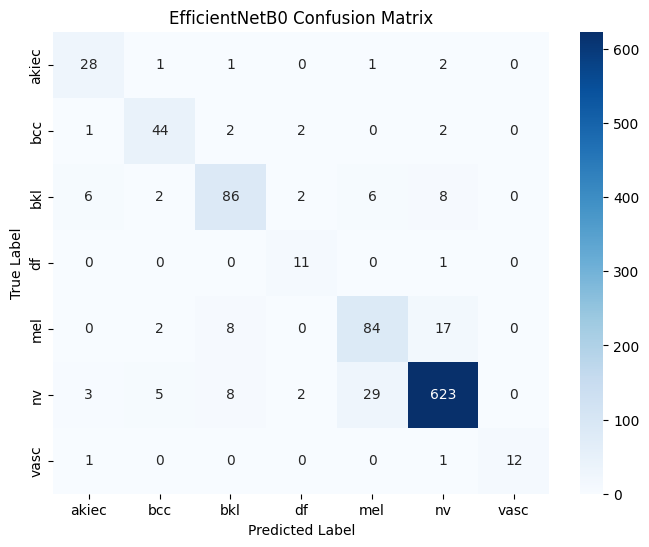

In [148]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")
plt.savefig(
    "EfficientNetB0_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show() 

In [149]:
cm_resnet_image = confusion_matrix(
    y_true_resnet_image,
    y_pred_resnet_image
)

cm_mobile_image = confusion_matrix(
    y_true_mobile_image,
    y_pred_mobile_image
)

cm_efficient_image = confusion_matrix(
    y_true_efficient_image,
    y_pred_efficient_image
)

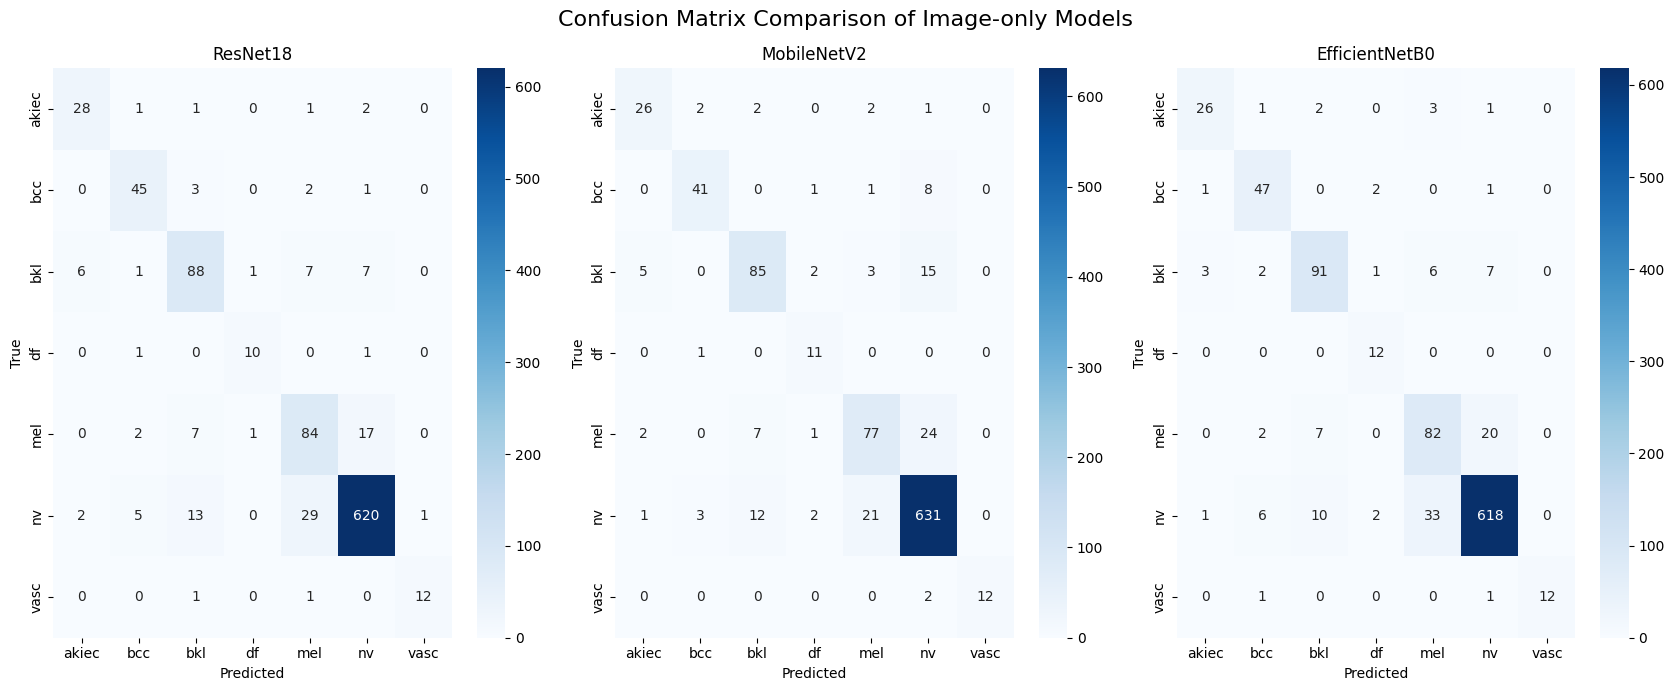

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(17, 7))

# ResNet18
sns.heatmap(
    cm_resnet_image,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("ResNet18")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# MobileNetV2
sns.heatmap(
    cm_mobile_image,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title("MobileNetV2")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

# EfficientNetB0
sns.heatmap(
    cm_efficient_image,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[2]
)

axes[2].set_title("EfficientNetB0")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

# Layout
plt.suptitle(
    "Confusion Matrix Comparison of Image-only Models",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "image_only_confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Comparative Analysis of Image-Only Deep Learning Architectures on HAM10000 Dataset

## Overview

This experiment evaluates three state-of-the-art convolutional neural network (CNN) architectures for multiclass skin lesion classification on the HAM10000 dataset:

1. ResNet18
2. MobileNetV2
3. EfficientNetB0

The objective is to identify the most effective image-based architecture before investigating multimodal fusion with clinical metadata.

Performance was assessed using:

* Accuracy
* Precision
* Recall
* F1-score
* Classification Reports
* Confusion Matrices
* Generalization Behavior

---

# Baseline: Metadata-Only Model

## Validation Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 45.64% |
| Macro F1    | 0.2322 |
| Weighted F1 | 0.5183 |

## Observations

The Metadata MLP achieved only 45.64% validation accuracy, significantly lower than all image-based models.

The model relied heavily on age, sex, and lesion location information but lacked visual information required for accurate diagnosis.

Major limitations include:

* Poor performance on minority classes.
* Complete failure to recognize vascular lesions (vasc).
* Strong bias toward the dominant nevus (nv) class.

## Conclusion

Metadata alone is insufficient for reliable skin lesion classification. However, it may provide complementary information when combined with image features.

---

# ResNet18 Analysis

## Validation Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 88.61% |
| Macro F1    | 0.8325 |
| Weighted F1 | 0.8882 |

## Test Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 88.02% |
| Macro F1    | 0.8030 |
| Weighted F1 | 0.8804 |

## Strengths

* Strong performance across most lesion categories.
* Excellent classification of the dominant nv class.
* High recall for melanoma (mel).
* Stable generalization with only a small validation-to-test drop.

## Weaknesses

* Lower precision for akiec.
* Moderate confusion between melanoma and nevus lesions.
* Slightly weaker minority-class performance compared to EfficientNetB0.

## Confusion Matrix Insights

Most classification errors occurred between:

* mel ↔ nv
* bkl ↔ mel

which is expected because these lesion types often share visual characteristics.

## Overall Assessment

ResNet18 provides strong performance while maintaining relatively low computational complexity. It serves as a reliable baseline architecture.

---

# MobileNetV2 Analysis

## Validation Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 88.21% |
| Macro F1    | 0.8189 |
| Weighted F1 | 0.8814 |

## Test Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 87.52% |
| Macro F1    | 0.8008 |
| Weighted F1 | 0.8771 |

## Strengths

* Lightweight architecture.
* Fast training and inference.
* Good classification of majority classes.
* Excellent precision for bcc.

## Weaknesses

* Lowest overall accuracy among the three CNN models.
* Higher confusion between melanoma and nevus lesions.
* Slightly weaker minority-class performance.

## Confusion Matrix Insights

MobileNetV2 showed:

* Increased confusion between bkl and nv.
* Increased confusion between mel and nv.

These errors indicate that the compressed architecture may sacrifice some discriminative capability.

## Overall Assessment

MobileNetV2 offers the best efficiency-to-performance tradeoff and is suitable for deployment on resource-constrained devices. However, it is not the most accurate architecture in this study.

---

# EfficientNetB0 Analysis

## Validation Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 88.71% |
| Macro F1    | 0.8401 |
| Weighted F1 | 0.8891 |

## Test Performance

| Metric      | Value  |
| ----------- | ------ |
| Accuracy    | 88.52% |
| Macro F1    | 0.8292 |
| Weighted F1 | 0.8866 |

## Strengths

* Highest validation accuracy.
* Highest test accuracy.
* Highest macro-average F1-score.
* Best minority-class performance.
* Strongest balance between precision and recall.

## Weaknesses

* Slightly higher computational cost than MobileNetV2.
* Melanoma remains the most challenging class.

## Confusion Matrix Insights

EfficientNetB0 demonstrated:

* Better separation between bkl and mel.
* Better recognition of minority classes.
* Reduced confusion across most lesion categories.

The confusion matrix exhibits the strongest diagonal structure, indicating superior class discrimination.

## Overall Assessment

EfficientNetB0 achieved the most balanced and consistent performance across all evaluation metrics.

---

# Generalization Analysis

Generalization was assessed by comparing validation and test performance.

| Model          | Validation Accuracy | Test Accuracy | Drop  |
| -------------- | ------------------- | ------------- | ----- |
| ResNet18       | 88.61%              | 88.02%        | 0.59% |
| MobileNetV2    | 88.21%              | 87.52%        | 0.69% |
| EfficientNetB0 | 88.71%              | 88.52%        | 0.19% |

## Observation

EfficientNetB0 exhibits the smallest validation-to-test performance gap.

This indicates:

* Better robustness.
* Better generalization.
* Lower susceptibility to overfitting.

---

# Minority-Class Analysis

The HAM10000 dataset is highly imbalanced, making minority-class recognition particularly important.

Classes with limited samples:

* akiec
* bcc
* df
* vasc

EfficientNetB0 achieved:

* Highest recall for bcc.
* Perfect recall for df on validation.
* Strong performance on vasc.
* Strong macro-average metrics.

This suggests superior learning of minority-class representations.

---

# Final Ranking

## Based on Validation Performance

1. EfficientNetB0 (88.71%)
2. ResNet18 (88.61%)
3. MobileNetV2 (88.21%)

## Based on Test Performance

1. EfficientNetB0 (88.52%)
2. ResNet18 (88.02%)
3. MobileNetV2 (87.52%)

## Based on Macro F1-Score

1. EfficientNetB0
2. ResNet18
3. MobileNetV2

## Based on Generalization

1. EfficientNetB0
2. ResNet18
3. MobileNetV2

---

# Conclusion

Among all image-only architectures evaluated on the HAM10000 dataset, EfficientNetB0 emerged as the strongest overall performer.

The model achieved:

* Highest validation accuracy
* Highest test accuracy
* Highest macro-average F1-score
* Best minority-class recognition
* Strongest generalization capability

ResNet18 performed competitively and remained a strong baseline model, while MobileNetV2 provided the most computationally efficient solution with only a minor reduction in accuracy.

Therefore, EfficientNetB0 was selected as the most suitable image backbone for subsequent multimodal fusion experiments involving clinical metadata.


## VALIDATION ACCURACY GRAPH

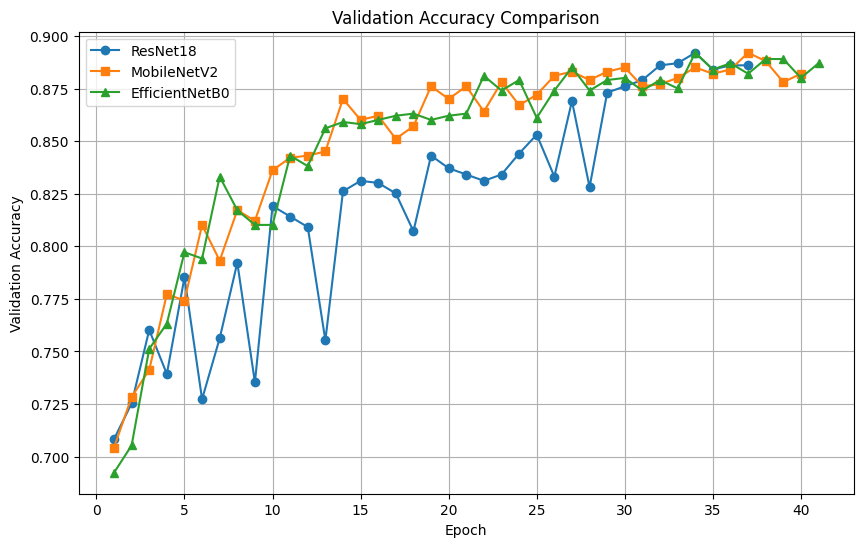

In [151]:
# Epoch Range
epochs_resnet = range(1, len(resnet_history["val_acc"]) + 1)
epochs_mobile = range(1, len(mobilenet_history["val_acc"]) + 1)
epochs_efficient = range(1, len(efficientnet_history["val_acc"]) + 1)

# Validation Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.plot(
    epochs_resnet,
    resnet_history["val_acc"],
    marker='o',
    label="ResNet18")

plt.plot(
    epochs_mobile,
    mobilenet_history["val_acc"],
    marker='s',
    label="MobileNetV2")

plt.plot(
    epochs_efficient,
    efficientnet_history["val_acc"],
    marker='^',
    label="EfficientNetB0"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.savefig(
    "validation_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## VALIDATION LOSS GRAPH

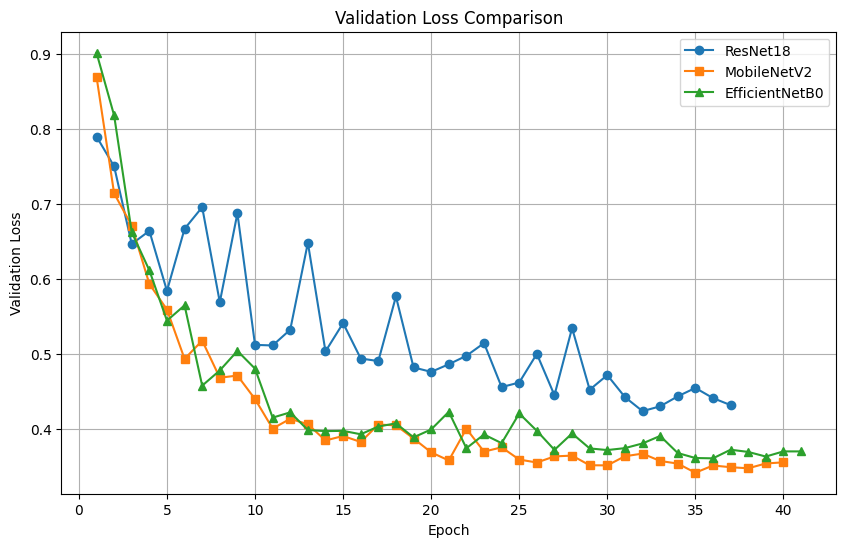

In [152]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_resnet,
    resnet_history["val_loss"],
    marker='o',
    label="ResNet18")

plt.plot(
    epochs_mobile,
    mobilenet_history["val_loss"],
    marker='s',
    label="MobileNetV2")

plt.plot(
    epochs_efficient,
    efficientnet_history["val_loss"],
    marker='^',
    label="EfficientNetB0")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.savefig(
    "validation_Loss_comparison.png",
    dpi=300,
    bbox_inches="tight") 
plt.show()

## Training vs validation Loss Comparison( visualizing generalization vs overfitting.)

#### 1. RESNET18 PLOT

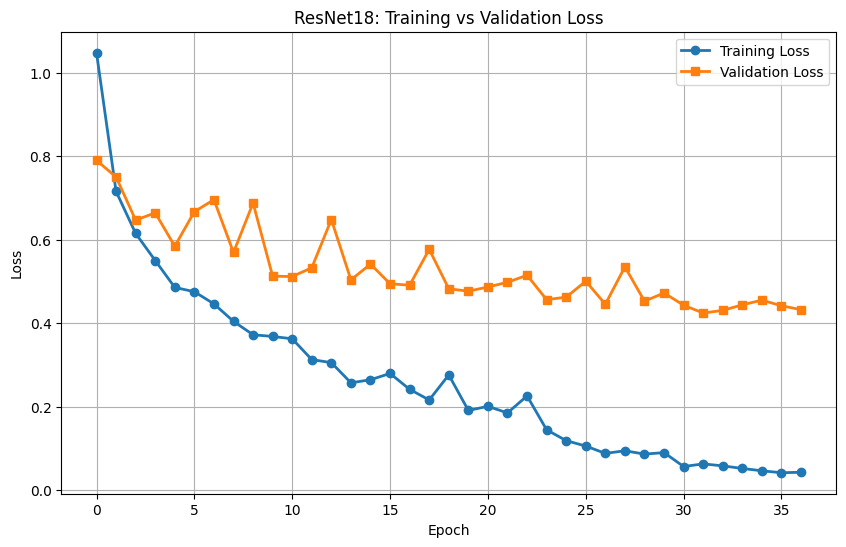

In [153]:
plt.figure(figsize=(10,6))
plt.plot(
    resnet_history["train_loss"],
    marker='o',
    linewidth=2,
    label='Training Loss')
plt.plot(
    resnet_history["val_loss"],
    marker='s',
    linewidth=2,
    label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(
    "ResNet18:_TrainingLoss_vs_ValidationLoss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 2. MOBILENETV2 PLOT

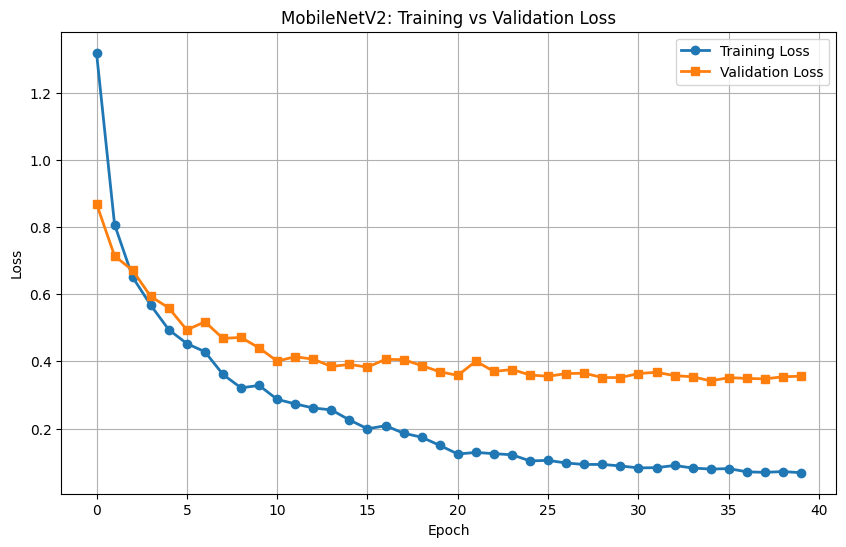

In [154]:
plt.figure(figsize=(10,6))

plt.plot(
    mobilenet_history["train_loss"],
    marker='o',
    linewidth=2,
    label='Training Loss')

plt.plot(
    mobilenet_history["val_loss"],
    marker='s',
    linewidth=2,
    label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(
    "MobileNetV2:_TrainingLoss_vs_ValidationLoss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### 3. EFFICIENTNETB0 PLOT

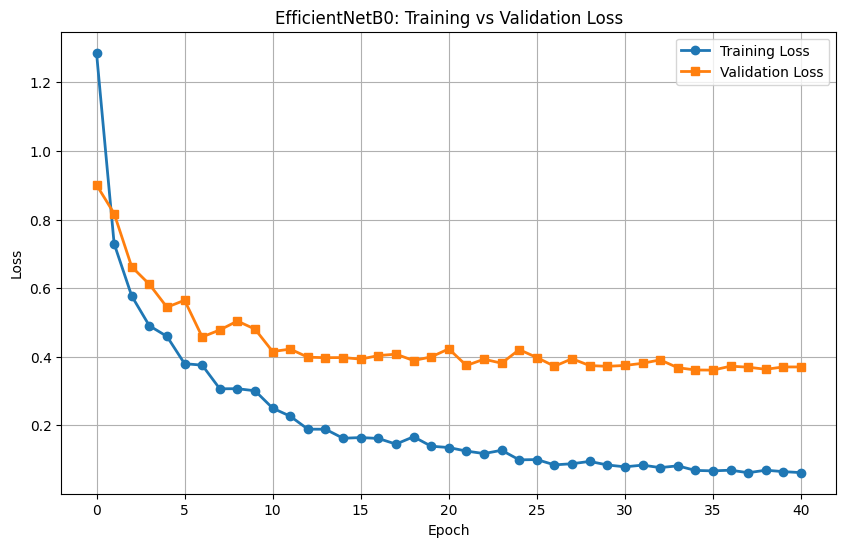

In [155]:
plt.figure(figsize=(10,6))

plt.plot(
    efficientnet_history["train_loss"],
    marker='o',
    linewidth=2,
    label='Training Loss')

plt.plot(
    efficientnet_history["val_loss"],
    marker='s',
    linewidth=2,
    label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(
    "EfficientNetB0:_TrainingLoss_vs_ValidationLoss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# (C). Multimodal fusion model

# Setting up fusion model


## — Build the Fusion Model Class( Architecture)

In [76]:
from torchvision.models import (
    resnet18,
    mobilenet_v2,
    efficientnet_b0,
    ResNet18_Weights,
    MobileNet_V2_Weights,
    EfficientNet_B0_Weights
)

class FusionModel(nn.Module):

    def __init__(self,backbone="resnet18",num_classes=7,
                 meta_input_dim=2+len(localization_feature_columns),
                 meta_hidden_dim=32):

        super().__init__()

        self.backbone_name=backbone

        # Backbone Selection

        if backbone=="resnet18":

            self.image_model=resnet18(
                weights=ResNet18_Weights.DEFAULT
            )

            self.image_feature_dim=(
                self.image_model.fc.in_features
            )

            self.image_model.fc=nn.Identity()

        elif backbone=="mobilenet":

            self.image_model=mobilenet_v2(
                weights=MobileNet_V2_Weights.DEFAULT
            )

            self.image_feature_dim=(
                self.image_model.classifier[1].in_features
            )

            self.image_model.classifier=nn.Identity()

        elif backbone=="efficientnet":

            self.image_model=efficientnet_b0(
                weights=EfficientNet_B0_Weights.DEFAULT
            )

            self.image_feature_dim=(
                self.image_model.classifier[1].in_features
            )

            self.image_model.classifier=nn.Identity()

        else:

            raise ValueError(
                "Choose: resnet18, mobilenet, or efficientnet"
            )

        # Metadata Branch

        self.meta_model=nn.Sequential(

            nn.Linear(
                meta_input_dim,
                meta_hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                meta_hidden_dim,
                meta_hidden_dim
            ),

            nn.ReLU()
        )

        # Gating Module

        self.gate=nn.Sequential(

            nn.Linear(
                meta_hidden_dim,
                self.image_feature_dim
            ),

            nn.Sigmoid()
        )

        # Fusion Classifier

        self.classifier=nn.Sequential(

            nn.Linear(
                self.image_feature_dim+
                meta_hidden_dim,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self,images,metadata):

        img_features=self.image_model(
            images
        )

        meta_features=self.meta_model(
            metadata
        )

        gate_weights=self.gate(
            meta_features
        )

        gated_img_features=(
            img_features*
            gate_weights
        )

        fused=torch.cat(
            [
                gated_img_features,
                meta_features
            ],
            dim=1
        )

        return self.classifier(
            fused
        )

## Experiment 1 ( ResNet18 Fusion ) 

In [77]:
# inititate the resnet model
fusion_resnet = FusionModel(
    backbone="resnet18",
    num_classes=7,
    meta_input_dim=2 + len(localization_feature_columns),
    meta_hidden_dim=32
).to(device)


# Load weights
fusion_resnet.image_model.load_state_dict(
    torch.load(
        "resnet18_finetuned.pth",
        weights_only=True
    ),
    strict=False
)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['fc.weight', 'fc.bias'])

## Experiment 2 ( MobileNet Fusion ) 

In [78]:
# inititate the Mobilenet model 
fusion_mobile = FusionModel(
    backbone="mobilenet",
    num_classes=7,
    meta_input_dim=2 + len(localization_feature_columns),
    meta_hidden_dim=32
).to(device) 

# load weights

fusion_mobile.image_model.load_state_dict(
    torch.load(
        "mobilenetv2_finetuned.pth",
        weights_only=True
    ),
    strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['classifier.1.weight', 'classifier.1.bias'])

##  Experiment 3 ( EfficientNet Fusion ) 

In [79]:
# inititate the Efficientnet model 
fusion_efficient = FusionModel(
    backbone="efficientnet",
    num_classes=7,
    meta_input_dim=2 + len(localization_feature_columns),
    meta_hidden_dim=32
).to(device)

# Transfer pretrained EfficientNetB0 weights into fusion backbone
fusion_efficient.image_model.load_state_dict(
    torch.load(
        "efficientnetb0_finetuned.pth",
        weights_only=True),
    strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['classifier.1.weight', 'classifier.1.bias'])

## STEP 2 — Decide Freezing Strategy

### Freeze / Unfreeze Function

### Resnet18

In [80]:
# freezing layer: 
# We are NOT training the image backbone during fusion training
for param in fusion_resnet.image_model.parameters():
    param.requires_grad = False

for param in fusion_resnet.image_model.layer3.parameters():
    param.requires_grad = True

for param in fusion_resnet.image_model.layer4.parameters():
    param.requires_grad = True

### Mobilenetv2

In [81]:
# Freezing layer
for param in fusion_mobile.image_model.parameters():
    param.requires_grad = False
    
# unfreezing layer    
for param in fusion_mobile.image_model.features[-2:].parameters():
    param.requires_grad = True

### EfficientnetB0

In [82]:
# freezing layer 
for param in fusion_efficient.image_model.parameters():
    param.requires_grad = False
    
# unfreezing layer 
for param in fusion_efficient.image_model.features[-2:].parameters():
    param.requires_grad = True

### Metadata MLP  +  Fusion head ( Trainable) for all models

In [83]:
# Make Sure Meta is Trainable  

# For fusion_resnet
for param in fusion_resnet.meta_model.parameters():
    param.requires_grad = True
for param in fusion_resnet.classifier.parameters():
    param.requires_grad = True

# For Mobilenet
for param in fusion_mobile.meta_model.parameters():
    param.requires_grad = True

for param in fusion_mobile.classifier.parameters():
    param.requires_grad = True

# for fusion_efficientnet
for param in fusion_efficient.meta_model.parameters():
    param.requires_grad = True
for param in fusion_efficient.classifier.parameters():
    param.requires_grad = True




## STEP 3 — Define Loss & Optimizer

In [195]:
criterion

CrossEntropyLoss()

### Resnet optimizer

In [196]:
# optimizer only for metamodel and fusion model
optimizer_fusion_resnet = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad, 
        fusion_resnet.parameters() #picks onlhy unfrozen parameters
    ),
    lr=1e-4
)

### Mobilenet Optimizer

In [197]:
# optimizer only for metamodel and fusion model
optimizer_fusion_mobile = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad, 
        fusion_mobile.parameters() #picks onlhy unfrozen parameters
    ),
    lr=1e-4
)

### Efficientnet Optimizer

In [198]:
# optimizer only for metamodel and fusion model
optimizer_fusion_efficient = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad, 
        fusion_efficient.parameters() #picks onlhy unfrozen parameters
    ),
    lr=1e-4
)

In [199]:
# verify resnet trainable parameters:

[name for name, p in fusion_resnet.named_parameters() if p.requires_grad]


['image_model.layer3.0.conv1.weight',
 'image_model.layer3.0.bn1.weight',
 'image_model.layer3.0.bn1.bias',
 'image_model.layer3.0.conv2.weight',
 'image_model.layer3.0.bn2.weight',
 'image_model.layer3.0.bn2.bias',
 'image_model.layer3.0.downsample.0.weight',
 'image_model.layer3.0.downsample.1.weight',
 'image_model.layer3.0.downsample.1.bias',
 'image_model.layer3.1.conv1.weight',
 'image_model.layer3.1.bn1.weight',
 'image_model.layer3.1.bn1.bias',
 'image_model.layer3.1.conv2.weight',
 'image_model.layer3.1.bn2.weight',
 'image_model.layer3.1.bn2.bias',
 'image_model.layer4.0.conv1.weight',
 'image_model.layer4.0.bn1.weight',
 'image_model.layer4.0.bn1.bias',
 'image_model.layer4.0.conv2.weight',
 'image_model.layer4.0.bn2.weight',
 'image_model.layer4.0.bn2.bias',
 'image_model.layer4.0.downsample.0.weight',
 'image_model.layer4.0.downsample.1.weight',
 'image_model.layer4.0.downsample.1.bias',
 'image_model.layer4.1.conv1.weight',
 'image_model.layer4.1.bn1.weight',
 'image_mode

In [200]:
# verify mobilenet trainable parameters:

[name for name, p in fusion_mobile.named_parameters() if p.requires_grad]


['image_model.features.17.conv.0.0.weight',
 'image_model.features.17.conv.0.1.weight',
 'image_model.features.17.conv.0.1.bias',
 'image_model.features.17.conv.1.0.weight',
 'image_model.features.17.conv.1.1.weight',
 'image_model.features.17.conv.1.1.bias',
 'image_model.features.17.conv.2.weight',
 'image_model.features.17.conv.3.weight',
 'image_model.features.17.conv.3.bias',
 'image_model.features.18.0.weight',
 'image_model.features.18.1.weight',
 'image_model.features.18.1.bias',
 'meta_model.0.weight',
 'meta_model.0.bias',
 'meta_model.3.weight',
 'meta_model.3.bias',
 'gate.0.weight',
 'gate.0.bias',
 'classifier.0.weight',
 'classifier.0.bias',
 'classifier.3.weight',
 'classifier.3.bias']

In [201]:
# verify efficient trainable parameters:

[name for name, p in fusion_efficient.named_parameters() if p.requires_grad]


['image_model.features.7.0.block.0.0.weight',
 'image_model.features.7.0.block.0.1.weight',
 'image_model.features.7.0.block.0.1.bias',
 'image_model.features.7.0.block.1.0.weight',
 'image_model.features.7.0.block.1.1.weight',
 'image_model.features.7.0.block.1.1.bias',
 'image_model.features.7.0.block.2.fc1.weight',
 'image_model.features.7.0.block.2.fc1.bias',
 'image_model.features.7.0.block.2.fc2.weight',
 'image_model.features.7.0.block.2.fc2.bias',
 'image_model.features.7.0.block.3.0.weight',
 'image_model.features.7.0.block.3.1.weight',
 'image_model.features.7.0.block.3.1.bias',
 'image_model.features.8.0.weight',
 'image_model.features.8.1.weight',
 'image_model.features.8.1.bias',
 'meta_model.0.weight',
 'meta_model.0.bias',
 'meta_model.3.weight',
 'meta_model.3.bias',
 'gate.0.weight',
 'gate.0.bias',
 'classifier.0.weight',
 'classifier.0.bias',
 'classifier.3.weight',
 'classifier.3.bias']

## STEP 4 — Training Loop (Multimodal)

In [202]:
#now we train the main model of our project

#### training fusion function

In [203]:

def train_one_epoch_fusion(model, loader, criterion, optimizer, device):

    model.train()
    running_loss = 0.0
    correct = 0

    for images, metadata, labels in loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)
        # =========================
        # Forward
        # =========================
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        # =========================
        # Backward
        # =========================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # =========================
        # Loss accumulation
        # =========================
        running_loss += loss.item() * images.size(0)

        # =========================
        # Accuracy calculation
        # =========================
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

    # =========================
    # Epoch metrics
    # =========================
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / len(loader.dataset)

    return epoch_loss, epoch_acc


#### validation fusion function

In [204]:
def validate_one_epoch_fusion(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, metadata, labels in loader:
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)
            
            # Forward
            outputs = model(images, metadata)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return epoch_loss, accuracy


#### LoaDER for fusion


In [205]:
#Note: Fusion uses the SAME multimodal loaders as the image-only model 
# multimodal loaders
multimodal_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
multimodal_val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False) 
multimodal_test_loader   = DataLoader(test_dataset, batch_size=32, shuffle=False) 

In [206]:
images, metadata, labels = next(iter(train_loader))

print(images.shape)    # should be [B, 3, 224, 224]
print(metadata.shape)  
print(labels.shape)   


torch.Size([32, 3, 224, 224])
torch.Size([32, 17])
torch.Size([32])


# Full training loop of fusion comparison M0dels

## Resnet18_FusionModel

In [207]:
num_epochs = 50

best_val_loss = float("inf")
patience = 8
epochs_without_improvement = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fusion_resnet,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)


resnet_fusion_train_losses = []
resnet_fusion_val_losses = []
resnet_fusion_train_accuracies = []
resnet_fusion_val_accuracies = []


for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_fusion(
        fusion_resnet,
        multimodal_train_loader,
        criterion,
        optimizer_fusion_resnet,
        device
    )

    val_loss, val_acc = validate_one_epoch_fusion(
        fusion_resnet,
        multimodal_val_loader,
        criterion,
        device
    )

    # Store history

    resnet_fusion_train_losses.append(train_loss)
    resnet_fusion_val_losses.append(val_loss)
    resnet_fusion_train_accuracies.append(train_acc)
    resnet_fusion_val_accuracies.append(val_acc)

    # Scheduler step

    scheduler.step(val_loss)

    # Save Best Model

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            fusion_resnet.state_dict(),
            "resnet_fusion_model.pth"
        )

        print("✔ Best model saved.")
        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # Current Learning Rate

    current_lr = optimizer_fusion_resnet.param_groups[0]['lr']

    # Epoch Results

    print(

        f"Fusion Epoch [{epoch+1}/{num_epochs}] | "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_acc:.4f} | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_acc:.4f} | "

        f"LR: {current_lr:.6f}"
    )

    # ==========================================
    # Early Stopping
    # ==========================================

    if epochs_without_improvement >= patience:

        print(

            f"\nEarly stopping triggered after "

            f"{patience} epochs without improvement."
        )

        break

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✔ Best model saved.
Fusion Epoch [1/50] | Train Loss: 0.6347 | Train Acc: 0.8369 | Val Loss: 0.5391 | Val Acc: 0.8591 | LR: 0.000100
No improvement for 1 epoch(s).
Fusion Epoch [2/50] | Train Loss: 0.2218 | Train Acc: 0.9125 | Val Loss: 0.5780 | Val Acc: 0.8262 | LR: 0.000100
No improvement for 2 epoch(s).
Fusion Epoch [3/50] | Train Loss: 0.2225 | Train Acc: 0.9175 | Val Loss: 0.5994 | Val Acc: 0.8402 | LR: 0.000100
No improvement for 3 epoch(s).
Fusion Epoch [4/50] | Train Loss: 0.1503 | Train Acc: 0.9329 | Val Loss: 0.7244 | Val Acc: 0.8352 | LR: 0.000100
No improvement for 4 epoch(s).
Fusion Epoch [5/50] | Train Loss: 0.1408 | Train Acc: 0.9377 | Val Loss: 0.7681 | Val Acc: 0.8591 | LR: 0.000050
No improvement for 5 epoch(s).
Fusion Epoch [6/50] | Train Loss: 0.1064 | Train Acc: 0.9483 | Val Loss: 0.7334 | Val Acc: 0.8751 | LR: 0.000050
No improvement for 6 epoch(s).
Fusion Epoch [7/50] | Train Loss: 0.0868 | Train Acc: 0.9584 | Val Loss: 0.6808 | Val Acc: 0.8731 | LR: 0.000050
No 

In [208]:
resnet_fusion_history = {
    "train_loss": resnet_fusion_train_losses,
    "val_loss": resnet_fusion_val_losses,
    "train_acc": resnet_fusion_train_accuracies,
    "val_acc": resnet_fusion_val_accuracies}

## Mobilenet_FusionModel

In [209]:
num_epochs = 50

best_val_loss = float("inf")
patience = 8
epochs_without_improvement = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fusion_mobile,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)


mobilenet_fusion_train_losses = []
mobilenet_fusion_val_losses = []
mobilenet_fusion_train_accuracies = []
mobilenet_fusion_val_accuracies = []


for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_fusion(
        fusion_mobile,
        multimodal_train_loader,
        criterion,
        optimizer_fusion_mobile,
        device
    )

    val_loss, val_acc = validate_one_epoch_fusion(
        fusion_mobile,
        multimodal_val_loader,
        criterion,
        device
    )

    # Store history

    mobilenet_fusion_train_losses.append(train_loss)
    mobilenet_fusion_val_losses.append(val_loss)
    mobilenet_fusion_train_accuracies.append(train_acc)
    mobilenet_fusion_val_accuracies.append(val_acc)

    # Scheduler step

    scheduler.step(val_loss)

    # Save Best Model

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            fusion_mobile.state_dict(),
            "mobilenet_fusion_model.pth"
        )

        print("✔ Best model saved.")
        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # Current Learning Rate

    current_lr = optimizer_fusion_mobile.param_groups[0]['lr']

    # Epoch Results

    print(

        f"Fusion Epoch [{epoch+1}/{num_epochs}] | "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_acc:.4f} | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_acc:.4f} | "

        f"LR: {current_lr:.6f}"
    )

    # ==========================================
    # Early Stopping
    # ==========================================

    if epochs_without_improvement >= patience:

        print(

            f"\nEarly stopping triggered after "

            f"{patience} epochs without improvement."
        )

        break

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✔ Best model saved.
Fusion Epoch [1/50] | Train Loss: 0.7256 | Train Acc: 0.8342 | Val Loss: 0.4980 | Val Acc: 0.8841 | LR: 0.000100
✔ Best model saved.
Fusion Epoch [2/50] | Train Loss: 0.1821 | Train Acc: 0.9296 | Val Loss: 0.4437 | Val Acc: 0.8741 | LR: 0.000100
No improvement for 1 epoch(s).
Fusion Epoch [3/50] | Train Loss: 0.1345 | Train Acc: 0.9375 | Val Loss: 0.4696 | Val Acc: 0.8801 | LR: 0.000100
No improvement for 2 epoch(s).
Fusion Epoch [4/50] | Train Loss: 0.1145 | Train Acc: 0.9415 | Val Loss: 0.5179 | Val Acc: 0.8701 | LR: 0.000100
No improvement for 3 epoch(s).
Fusion Epoch [5/50] | Train Loss: 0.1170 | Train Acc: 0.9453 | Val Loss: 0.4739 | Val Acc: 0.8791 | LR: 0.000100
No improvement for 4 epoch(s).
Fusion Epoch [6/50] | Train Loss: 0.1078 | Train Acc: 0.9463 | Val Loss: 0.4983 | Val Acc: 0.8811 | LR: 0.000050
No improvement for 5 epoch(s).
Fusion Epoch [7/50] | Train Loss: 0.0905 | Train Acc: 0.9512 | Val Loss: 0.4963 | Val Acc: 0.8811 | LR: 0.000050
No improvement

In [210]:
mobilenet_fusion_history = {
    "train_loss": mobilenet_fusion_train_losses,
    "val_loss": mobilenet_fusion_val_losses,
    "train_acc": mobilenet_fusion_train_accuracies,
    "val_acc": mobilenet_fusion_val_accuracies}

## Efficientnet_Fusionmodel

In [211]:
num_epochs = 50

best_val_loss = float("inf")
patience = 8
epochs_without_improvement = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fusion_efficient,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)


efficientnet_fusion_train_losses = []
efficientnet_fusion_val_losses = []
efficientnet_fusion_train_accuracies = []
efficientnet_fusion_val_accuracies = []


for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch_fusion(
        fusion_efficient,
        multimodal_train_loader,
        criterion,
        optimizer_fusion_efficient,
        device
    )

    val_loss, val_acc = validate_one_epoch_fusion(
        fusion_efficient,
        multimodal_val_loader,
        criterion,
        device
    )

    # Store history

    efficientnet_fusion_train_losses.append(train_loss)
    efficientnet_fusion_val_losses.append(val_loss)
    efficientnet_fusion_train_accuracies.append(train_acc)
    efficientnet_fusion_val_accuracies.append(val_acc)

    # Scheduler step

    scheduler.step(val_loss)

    # Save Best Model

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            fusion_efficient.state_dict(),
            "efficientnet_fusion_model.pth"
        )

        print("✔ Best model saved.")
        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # Current Learning Rate

    current_lr = optimizer_fusion_efficient.param_groups[0]['lr']

    # Epoch Results

    print(

        f"Fusion Epoch [{epoch+1}/{num_epochs}] | "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_acc:.4f} | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_acc:.4f} | "

        f"LR: {current_lr:.6f}"
    )

    # ==========================================
    # Early Stopping
    # ==========================================

    if epochs_without_improvement >= patience:

        print(

            f"\nEarly stopping triggered after "

            f"{patience} epochs without improvement."
        )

        break

/home/wasidkhan/torch-venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✔ Best model saved.
Fusion Epoch [1/50] | Train Loss: 0.5674 | Train Acc: 0.8415 | Val Loss: 0.4370 | Val Acc: 0.8821 | LR: 0.000100
No improvement for 1 epoch(s).
Fusion Epoch [2/50] | Train Loss: 0.1252 | Train Acc: 0.9500 | Val Loss: 0.4540 | Val Acc: 0.8841 | LR: 0.000100
No improvement for 2 epoch(s).
Fusion Epoch [3/50] | Train Loss: 0.1223 | Train Acc: 0.9450 | Val Loss: 0.4605 | Val Acc: 0.8791 | LR: 0.000100
No improvement for 3 epoch(s).
Fusion Epoch [4/50] | Train Loss: 0.1037 | Train Acc: 0.9500 | Val Loss: 0.4832 | Val Acc: 0.8831 | LR: 0.000100
No improvement for 4 epoch(s).
Fusion Epoch [5/50] | Train Loss: 0.1021 | Train Acc: 0.9513 | Val Loss: 0.5442 | Val Acc: 0.8911 | LR: 0.000050
No improvement for 5 epoch(s).
Fusion Epoch [6/50] | Train Loss: 0.0858 | Train Acc: 0.9516 | Val Loss: 0.5223 | Val Acc: 0.8861 | LR: 0.000050
No improvement for 6 epoch(s).
Fusion Epoch [7/50] | Train Loss: 0.0908 | Train Acc: 0.9533 | Val Loss: 0.4881 | Val Acc: 0.8841 | LR: 0.000050
No 

In [212]:
efficientnet_fusion_history = {
    "train_loss": efficientnet_fusion_train_losses,
    "val_loss": efficientnet_fusion_val_losses,
    "train_acc": efficientnet_fusion_train_accuracies,
    "val_acc": efficientnet_fusion_val_accuracies}

#  Evaluation

## Evaluate ResNet Fusion

In [213]:
fusion_resnet.eval()

y_true_resnet = []
y_pred_resnet = []

all_preds_resnet = []
all_labels_resnet = []

with torch.no_grad():

    for images, metadata, labels in multimodal_val_loader:

        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = fusion_resnet(images,metadata)

        preds = torch.argmax(outputs,dim=1)

        y_true_resnet.extend(labels.cpu().numpy())

        y_pred_resnet.extend(preds.cpu().numpy())

        all_preds_resnet.append(preds.cpu().numpy())

        all_labels_resnet.append(labels.cpu().numpy())

all_preds_resnet = np.concatenate(all_preds_resnet)

all_labels_resnet = np.concatenate(all_labels_resnet)

class_names = [
    'akiec',
    'bcc',
    'bkl',
    'df',
    'mel',
    'nv',
    'vasc'
]

print(
    classification_report(
        all_labels_resnet,
        all_preds_resnet,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       akiec     0.8261    0.5758    0.6786        33
         bcc     0.8113    0.8431    0.8269        51
         bkl     0.6984    0.8000    0.7458       110
          df     0.8333    0.8333    0.8333        12
         mel     0.6807    0.7297    0.7043       111
          nv     0.9527    0.9313    0.9419       670
        vasc     0.9231    0.8571    0.8889        14

    accuracy                         0.8761      1001
   macro avg     0.8179    0.7958    0.8028      1001
weighted avg     0.8814    0.8761    0.8774      1001



## Evaluate Mobilenet fusion

In [214]:
fusion_mobile.eval()

y_true_mobile = []
y_pred_mobile = []

all_preds_mobile = []
all_labels_mobile = []

with torch.no_grad():
    for images, metadata, labels in multimodal_val_loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = fusion_mobile(images, metadata)
        preds = torch.argmax(outputs, dim=1)
        
        y_true_mobile.extend(labels.cpu().numpy())
        y_pred_mobile.extend(preds.cpu().numpy())

        all_preds_mobile.append(preds.cpu().numpy())
        all_labels_mobile.append(labels.cpu().numpy())

all_preds_mobile = np.concatenate(all_preds_mobile)
all_labels_mobile = np.concatenate(all_labels_mobile)

class_names = ['akiec','bcc','bkl','df','mel','nv','vasc']

print(classification_report(
    all_labels_mobile,
    all_preds_mobile,
    target_names=class_names,
    digits=4 ))

              precision    recall  f1-score   support

       akiec     0.8065    0.7576    0.7812        33
         bcc     0.8367    0.8039    0.8200        51
         bkl     0.8367    0.7455    0.7885       110
          df     0.6875    0.9167    0.7857        12
         mel     0.6967    0.7658    0.7296       111
          nv     0.9361    0.9403    0.9382       670
        vasc     1.0000    0.8571    0.9231        14

    accuracy                         0.8851      1001
   macro avg     0.8286    0.8267    0.8238      1001
weighted avg     0.8872    0.8851    0.8854      1001



##  Evaluate Efficientnet fusion

In [215]:
fusion_efficient.eval()

y_true_efficient = []
y_pred_efficient = []

all_preds_efficient = []
all_labels_efficient = []

with torch.no_grad():
    for images, metadata, labels in multimodal_val_loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = fusion_efficient(images, metadata)
        preds = torch.argmax(outputs, dim=1)
        
        y_true_efficient.extend(labels.cpu().numpy())
        y_pred_efficient.extend(preds.cpu().numpy())

        all_preds_efficient.append(preds.cpu().numpy())
        all_labels_efficient.append(labels.cpu().numpy())

all_preds_efficient = np.concatenate(all_preds_efficient)
all_labels_efficient = np.concatenate(all_labels_efficient)

class_names = ['akiec','bcc','bkl','df','mel','nv','vasc']

print(classification_report(
    all_labels_efficient,
    all_preds_efficient,
    target_names=class_names,
    digits=4 ))

              precision    recall  f1-score   support

       akiec     0.7941    0.8182    0.8060        33
         bcc     0.7797    0.9020    0.8364        51
         bkl     0.7440    0.8455    0.7915       110
          df     0.7500    1.0000    0.8571        12
         mel     0.7941    0.7297    0.7606       111
          nv     0.9557    0.9328    0.9441       670
        vasc     1.0000    0.7857    0.8800        14

    accuracy                         0.8941      1001
   macro avg     0.8311    0.8591    0.8394      1001
weighted avg     0.8983    0.8941    0.8950      1001



# Test Evaluation

## Resnet18 test evalutation 

In [216]:
fusion_resnet.load_state_dict(
    torch.load(
        "resnet_fusion_model.pth",
        weights_only=True
    )
)

fusion_resnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, metadata, labels in multimodal_test_loader:

        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = fusion_resnet(
            images,
            metadata
        )

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("\n===== ResNet18 Fusion Test Report =====\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


===== ResNet18 Fusion Test Report =====

              precision    recall  f1-score   support

       akiec     0.5833    0.6562    0.6176        32
         bcc     0.7778    0.8077    0.7925        52
         bkl     0.7692    0.8182    0.7930       110
          df     0.7500    0.8182    0.7826        11
         mel     0.6138    0.7946    0.6926       112
          nv     0.9711    0.9001    0.9343       671
        vasc     0.8125    0.9286    0.8667        14

    accuracy                         0.8663      1002
   macro avg     0.7540    0.8177    0.7827      1002
weighted avg     0.8819    0.8663    0.8717      1002



## Mobilenetv2 test evalutation 

In [217]:
fusion_mobile.load_state_dict(
    torch.load(
        "mobilenet_fusion_model.pth",
        weights_only=True
    )
)

fusion_mobile.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, metadata, labels in multimodal_test_loader:

        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = fusion_mobile(
            images,
            metadata
        )

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("\n===== MobileNetV2 Fusion Test Report =====\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


===== MobileNetV2 Fusion Test Report =====

              precision    recall  f1-score   support

       akiec     0.5952    0.7812    0.6757        32
         bcc     0.9038    0.9038    0.9038        52
         bkl     0.8617    0.7364    0.7941       110
          df     0.6667    0.9091    0.7692        11
         mel     0.5959    0.7768    0.6744       112
          nv     0.9592    0.9106    0.9343       671
        vasc     0.8125    0.9286    0.8667        14

    accuracy                         0.8723      1002
   macro avg     0.7707    0.8495    0.8026      1002
weighted avg     0.8881    0.8723    0.8772      1002



##  Efficientnet test evalutation 

In [218]:
fusion_efficient.load_state_dict(
    torch.load(
        "efficientnet_fusion_model.pth",
        weights_only=True
    )
)

fusion_efficient.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, metadata, labels in multimodal_test_loader:

        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = fusion_efficient(
            images,
            metadata
        )

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("\n===== EfficientNetB0 Fusion Test Report =====\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


===== EfficientNetB0 Fusion Test Report =====

              precision    recall  f1-score   support

       akiec     0.7407    0.6250    0.6780        32
         bcc     0.8846    0.8846    0.8846        52
         bkl     0.7311    0.7909    0.7598       110
          df     0.8462    1.0000    0.9167        11
         mel     0.6615    0.7679    0.7107       112
          nv     0.9612    0.9240    0.9422       671
        vasc     0.8125    0.9286    0.8667        14

    accuracy                         0.8812      1002
   macro avg     0.8054    0.8458    0.8227      1002
weighted avg     0.8881    0.8812    0.8836      1002



## Confusion Matrix of Resnet_fusion

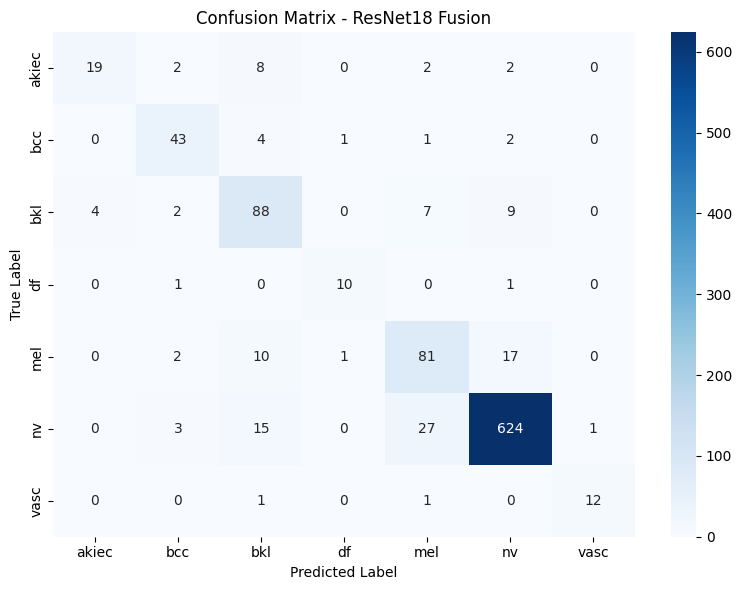

In [220]:
cm_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet18 Fusion")

plt.tight_layout()

plt.savefig(
    "resnet18_fusion_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Confusion Matrix of Mobilenet_fusion

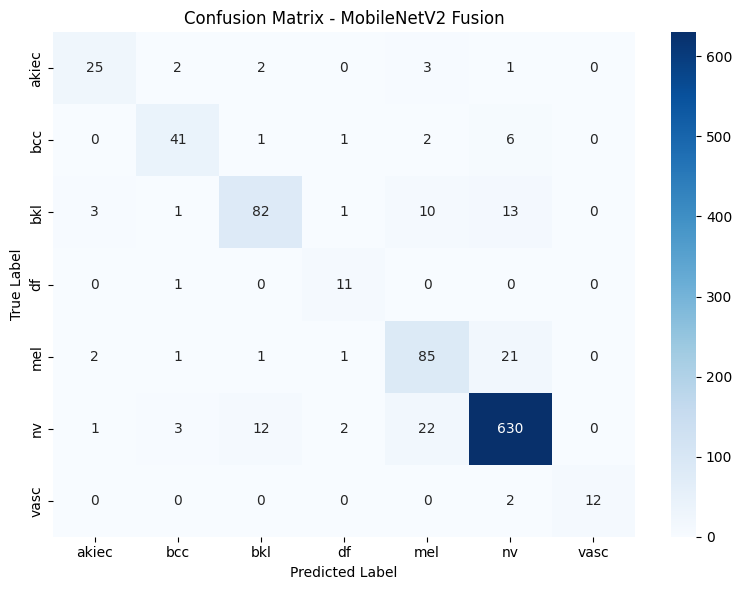

In [221]:
cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2 Fusion")

plt.tight_layout()

plt.savefig(
    "mobilenetv2_fusion_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Confusion Matrix of Efficientnet_fusion

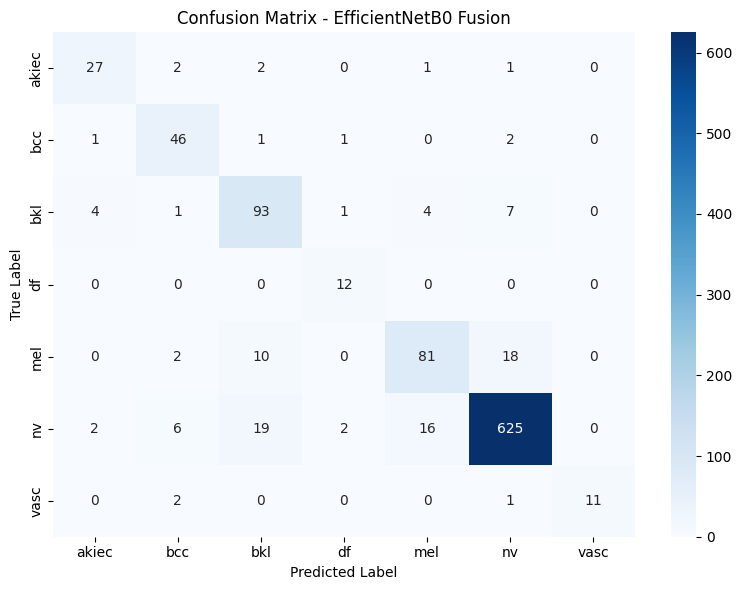

In [222]:
cm_efficient = confusion_matrix(
    y_true_efficient,
    y_pred_efficient
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_efficient,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - EfficientNetB0 Fusion")

plt.tight_layout()

plt.savefig(
    "efficientnetb0_fusion_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

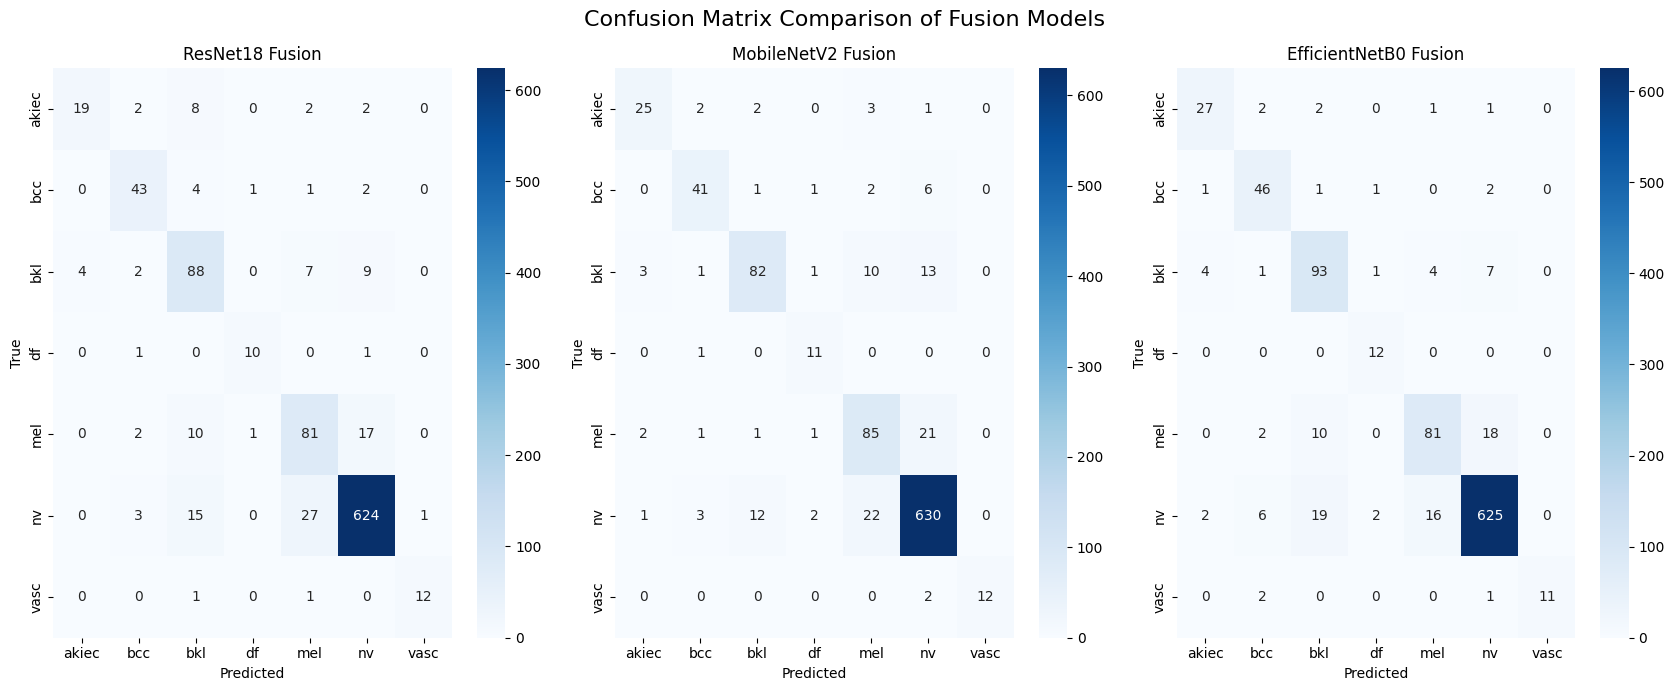

In [223]:

fig, axes = plt.subplots(1, 3, figsize=(17, 7))

# ResNet18 Fusion
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("ResNet18 Fusion")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# MobileNetV2 Fusion
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title("MobileNetV2 Fusion")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

# EfficientNetB0 Fusion
sns.heatmap(
    cm_efficient,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[2]
)

axes[2].set_title("EfficientNetB0 Fusion")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

# Layout
plt.suptitle(
    "Confusion Matrix Comparison of Fusion Models",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "fusion_confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 1. Comparative Analysis of Simple concat Fusion Architectures on HAM10000 Dataset

## Overview

After evaluating image-only CNN architectures, a multimodal fusion framework was developed to investigate whether clinical metadata could improve skin lesion classification performance.

The fusion architecture combines:

1. Image Features (CNN Backbone)
2. Clinical Metadata Features (MLP)
3. Feature Fusion Layer
4. Final Classification Head

Three fusion variants were evaluated:

- ResNet18 + Metadata
- MobileNetV2 + Metadata
- EfficientNetB0 + Metadata

The metadata branch received:

- Age
- Sex
- Localization Features

and transformed them through a small MLP before concatenation with image features extracted by the CNN backbone.

### RQs:
The primary objective was to determine:

- Whether metadata improves classification performance.
- Which fusion architecture benefits most from metadata.
- Whether multimodal fusion outperforms image-only learning.

---

# Fusion Architecture Performance Summary

## Validation Results

| Model | Validation Accuracy | Macro F1 |
|---------|---------|---------|
| ResNet18 Fusion | 85.11% | 0.6403 |
| MobileNetV2 Fusion | 88.31% | 0.8334 |
| EfficientNetB0 Fusion | 88.61% | 0.8330 |

## Test Results

| Model | Test Accuracy | Macro F1 |
|---------|---------|---------|
| ResNet18 Fusion | 86.93% | 0.7481 |
| MobileNetV2 Fusion | 86.23% | 0.7901 |
| EfficientNetB0 Fusion | 88.32% | 0.8225 |

---

# ResNet18 Fusion Analysis

## Validation Performance

- Accuracy: 85.11%
- Macro F1: 0.6403

## Test Performance

- Accuracy: 86.93%
- Macro F1: 0.7481

## Strengths

- Strong nevus (nv) classification.
- Improved recall for akiec compared to image-only test results.
- Better melanoma recall than expected.

## Weaknesses

- Significant degradation compared to image-only ResNet18.
- Failed completely on vasc during validation.
- Reduced melanoma discrimination.
- Large confusion between melanoma and nevus classes.

## Confusion Matrix Analysis

The confusion matrix reveals heavy misclassification:

- mel → nv
- bkl → nv

indicating that metadata did not provide additional discriminative information and may have introduced noise into the learning process.

## Conclusion

Fusion degraded overall ResNet18 performance and reduced its generalization capability.

---

# MobileNetV2 Fusion Analysis

## Validation Performance

- Accuracy: 88.31%
- Macro F1: 0.8334

## Test Performance

- Accuracy: 86.23%
- Macro F1: 0.7901

## Strengths

- Strong minority-class recognition.
- Excellent performance on vasc.
- Good melanoma recall.
- Improved macro-average metrics.

## Weaknesses

- Test accuracy decreased relative to image-only MobileNetV2.
- Larger validation-to-test drop.
- Increased confusion among bkl, mel, and nv classes.

## Confusion Matrix Analysis

The model successfully classified:

- df
- vasc
- bcc

However, performance deteriorated for:

- bkl
- melanoma

during test evaluation.

## Conclusion

Metadata improved minority-class sensitivity but did not improve overall classification accuracy.

---

# EfficientNetB0 Fusion Analysis

## Validation Performance

- Accuracy: 88.61%
- Macro F1: 0.8330

## Test Performance

- Accuracy: 88.32%
- Macro F1: 0.8225

## Strengths

- Highest fusion test accuracy.
- Best overall balance between precision and recall.
- Strong performance across all lesion categories.
- Excellent recognition of minority classes.
- Most stable fusion architecture.

## Weaknesses

- Improvement over image-only EfficientNetB0 was negligible.
- Metadata contribution remained limited.

## Confusion Matrix Analysis

EfficientNet Fusion displayed:

- Strong diagonal dominance.
- Reduced confusion among minority classes.
- Better melanoma recognition than ResNet Fusion.

Most remaining errors occurred between:

- mel ↔ nv
- bkl ↔ mel

which are known challenging categories in HAM10000.

## Conclusion

EfficientNetB0 remained the strongest backbone after fusion and demonstrated the best robustness among all multimodal models.

---

# Image-Only vs Fusion Comparison

## Validation Accuracy

| Model | Image Only | Fusion | Change |
|---------|---------|---------|---------|
| ResNet18 | 88.61% | 85.11% | -3.50% |
| MobileNetV2 | 88.21% | 88.31% | +0.10% |
| EfficientNetB0 | 88.71% | 88.61% | -0.10% |

---

## Test Accuracy

| Model | Image Only | Fusion | Change |
|---------|---------|---------|---------|
| ResNet18 | 88.02% | 86.93% | -1.09% |
| MobileNetV2 | 87.52% | 86.23% | -1.29% |
| EfficientNetB0 | 88.52% | 88.32% | -0.20% |

---

# Did Metadata Help?

## Accuracy Perspective

The addition of metadata did not produce meaningful gains in overall accuracy.

Across all architectures:

- No fusion model surpassed the corresponding image-only model on the test set.
- The best fusion model remained slightly below its image-only counterpart.

This suggests that image information already captured most discriminative features required for diagnosis.

---

## Minority-Class Perspective

Metadata provided some benefits:

### Improvements Observed

- Better recall for akiec.
- Better detection of df.
- Better recognition of vasc.
- Improved macro-average metrics for some models.

### Limitations

These improvements were offset by:

- Increased confusion among major classes.
- Reduced precision in melanoma prediction.
- Slight reduction in overall accuracy.

---

# Why Did Metadata Not Improve Performance Significantly?

Several factors may explain this behavior.

## 1. Weak Clinical Signal

The available metadata consists of:

- Age
- Sex
- Localization

While useful, these variables provide only limited diagnostic information compared with dermoscopic images.

---

## 2. Strong Visual Features

HAM10000 images contain rich visual patterns including:

- Color variation
- Pigment structures
- Border irregularities
- Texture information

The CNN backbones may already capture most diagnostic information independently.

---

## 3. Class Imbalance

The dominant nv class accounts for a large portion of the dataset.

Consequently:

- CNNs learn strong visual representations.
- Metadata contributes relatively little additional information.

---

## 4. Simple Fusion Strategy

The current architecture uses feature concatenation:

Image Features + Metadata Features → Classifier

This early-fusion approach may not optimally exploit metadata relationships.

More advanced approaches could include:

- Attention-based fusion
- Cross-modal transformers
- Gated multimodal networks
- Feature weighting mechanisms

---

# Overall Ranking of Fusion Models

## Based on Test Accuracy

1. EfficientNetB0 Fusion (88.32%)
2. ResNet18 Fusion (86.93%)
3. MobileNetV2 Fusion (86.23%)

## Based on Macro F1

1. EfficientNetB0 Fusion (0.8225)
2. MobileNetV2 Fusion (0.7901)
3. ResNet18 Fusion (0.7481)

## Based on Stability

1. EfficientNetB0 Fusion
2. MobileNetV2 Fusion
3. ResNet18 Fusion

---

# Final Comparison: Best Overall Models

## Image-Only Models

| Rank | Model | Test Accuracy |
|--------|--------|--------|
| 1 | EfficientNetB0 | 88.52% |
| 2 | ResNet18 | 88.02% |
| 3 | MobileNetV2 | 87.52% |

## Fusion Models

| Rank | Model | Test Accuracy |
|--------|--------|--------|
| 1 | EfficientNetB0 Fusion | 88.32% |
| 2 | ResNet18 Fusion | 86.93% |
| 3 | MobileNetV2 Fusion | 86.23% |

---

# Final Conclusion

This study investigated both image-only and multimodal fusion architectures for skin lesion classification on the HAM10000 dataset.

Among all image-only models, EfficientNetB0 achieved the best overall performance with a test accuracy of 88.52% and the strongest balance between minority-class recognition and generalization capability.

The proposed fusion framework successfully incorporated clinical metadata through an MLP branch; however, metadata contributed only marginal benefits and did not significantly improve overall classification performance.

Although some gains were observed for minority classes such as df, akiec, and vasc, these improvements were offset by increased confusion among major lesion categories.

Consequently, image-only EfficientNetB0 remained the strongest overall model in this study, while EfficientNetB0 Fusion emerged as the best multimodal architecture.

The findings suggest that dermoscopic image features carry substantially greater diagnostic value than the available metadata attributes within the HAM10000 dataset. Future work may explore more sophisticated multimodal fusion strategies to better exploit complementary 
clinical information.

------------------------------------------------------------------------------------------------------------------------------------------

* The fusion models did not significantly outperform the image-only models. This indicates that the visual features extracted by the CNN architectures already capture most of the discriminative information required for lesion classification. While metadata contributed to improved recognition of certain minority classes, its overall impact on classification accuracy was limited.

# 2. Comparative Attention-Based Fusion  Analysis on HAM10000 Dataset  -- Experiment

## Objective

An attention-based fusion mechanism was investigated to determine whether metadata could provide more informative guidance to image features compared to simple feature concatenation.

Instead of directly concatenating image and metadata representations, metadata features were first used to generate attention weights that modulated the image feature vector before fusion and classification.

---

# Validation Performance

| Model                           | Validation Accuracy | Macro F1 | Weighted F1 |
| ------------------------------- | ------------------- | -------- | ----------- |
| ResNet18 Attention Fusion       | 88.21%              | 0.8152   | 0.8851      |
| MobileNetV2 Attention Fusion    | 88.41%              | 0.8237   | 0.8847      |
| EfficientNetB0 Attention Fusion | 87.61%              | 0.8223   | 0.8786      |

---

# Test Performance

| Model                           | Test Accuracy | Macro F1 | Weighted F1 |
| ------------------------------- | ------------- | -------- | ----------- |
| ResNet18 Attention Fusion       | 84.73%        | 0.7418   | 0.8532      |
| MobileNetV2 Attention Fusion    | 86.23%        | 0.7901   | 0.8674      |
| EfficientNetB0 Attention Fusion | 86.93%        | 0.8139   | 0.8738      |

---

# Comparison with Simple Concatenation Fusion

| Model          | Simple Fusion | Attention Fusion | Difference |
| -------------- | ------------- | ---------------- | ---------- |
| ResNet18       | 86.93%        | 84.73%           | -2.20%     |
| MobileNetV2    | 86.23%        | 86.23%           | 0.00%      |
| EfficientNetB0 | 88.32%        | 86.93%           | -1.39%     |

---

# Observations

### ResNet18

The attention mechanism resulted in a noticeable decline in test accuracy compared with simple fusion. Although validation accuracy remained competitive, the larger validation-to-test gap suggests reduced generalization capability.

### MobileNetV2

Attention fusion produced nearly identical performance to simple concatenation. This indicates that metadata-guided weighting did not significantly alter the discriminative power of the learned image features.

### EfficientNetB0

EfficientNetB0 remained the strongest attention-based fusion model; however, its performance decreased relative to both the image-only baseline and the simple fusion approach. The attention module did not provide additional useful information and may have suppressed informative image features.

---

# General Findings

The introduction of metadata-guided attention did not improve classification performance on the HAM10000 dataset.

Possible explanations include:

* The image backbone already captures most diagnostically relevant information.
* Metadata variables (age, sex, localization) provide limited additional discriminative value.
* The simple attention mechanism may not be sufficiently expressive to model complex image-metadata interactions.
* Attention weighting may unintentionally suppress useful visual features learned by the CNN backbone.

---

# Ranking of Attention Fusion Models

1. EfficientNetB0 Attention Fusion (86.93%)
2. MobileNetV2 Attention Fusion (86.23%)
3. ResNet18 Attention Fusion (84.73%)

---

# Conclusion

Attention-based fusion did not outperform either image-only models or simple concatenation fusion on the HAM10000 dataset.

The strongest attention-based model, EfficientNetB0 Attention Fusion, achieved a test accuracy of 86.93%, which remained below the image-only EfficientNetB0 baseline (88.52%) and the simple EfficientNetB0 fusion model (88.32%).

These findings suggest that the selected metadata attributes contribute limited complementary information and that simple metadata-guided attention is insufficient to improve skin lesion classification performance in this experimental setting.


# 3. Comparative Analysis of Gated Fusion Models on HAM10000 Dataset

## Overview

This experiment evaluates Gated Fusion as an alternative multimodal fusion strategy for combining image features and clinical metadata.

Unlike simple concatenation, Gated Fusion learns feature-wise importance weights from metadata and uses these weights to selectively emphasize or suppress image features before fusion.

The objective is to determine whether metadata can be utilized more effectively through gating mechanisms and whether Gated Fusion can outperform both Image-Only and previous Fusion approaches?

---

# ResNet18 Gated Fusion

## Validation Performance

| Metric | Value |
|----------|----------|
| Accuracy | 87.61% |
| Macro F1 | 0.8028 |
| Weighted F1 | 0.8774 |

## Test Performance

| Metric | Value |
|----------|----------|
| Accuracy | 86.63% |
| Macro F1 | 0.7827 |
| Weighted F1 | 0.8717 |

## Observations

### Strengths

* Improved melanoma recall (79.46%).
* Strong nevus classification performance.
* Good minority-class recognition for df and vasc.

### Weaknesses

* Lower overall accuracy than Image-Only ResNet18.
* Significant decrease in akiec recall.
* Larger validation-to-test drop indicating weaker generalization.

### Conclusion

Gated Fusion did not improve ResNet18 and slightly degraded overall performance.

---

# MobileNetV2 Gated Fusion

## Validation Performance

| Metric | Value |
|----------|----------|
| Accuracy | 88.51% |
| Macro F1 | 0.8238 |
| Weighted F1 | 0.8854 |

## Test Performance

| Metric | Value |
|----------|----------|
| Accuracy | 87.23% |
| Macro F1 | 0.8026 |
| Weighted F1 | 0.8772 |

## Observations

### Strengths

* Best melanoma recall among MobileNet variants.
* Strong bcc performance.
* Good minority-class recognition.

### Weaknesses

* Accuracy remains below MobileNet Image-Only baseline.
* Increased confusion between melanoma and nevus lesions.
* Larger validation-to-test performance gap.

### Conclusion

Gated Fusion provides some class-specific benefits but fails to improve overall MobileNetV2 performance.

---

# EfficientNetB0 Gated Fusion

## Validation Performance

| Metric | Value |
|----------|----------|
| Accuracy | 89.41% |
| Macro F1 | 0.8394 |
| Weighted F1 | 0.8950 |

## Test Performance

| Metric | Value |
|----------|----------|
| Accuracy | 88.12% |
| Macro F1 | 0.8227 |
| Weighted F1 | 0.8836 |

## Observations

### Strengths

* Highest validation accuracy among all gated models.
* Strong performance across minority classes.
* Excellent df recognition.
* Highest validation weighted F1-score.

### Weaknesses

* Test accuracy remains below EfficientNetB0 Image-Only baseline.
* Noticeable validation-to-test drop.
* Metadata contributes limited additional discriminative information.

### Conclusion

EfficientNetB0 remains the strongest gated model, but gains do not translate to improved test performance.

---

# Confusion Matrix Analysis

## ResNet18 Gated Fusion

Major confusion remains between:

* mel ↔ nv
* bkl ↔ nv

Metadata gating slightly improves melanoma detection but introduces additional confusion in other classes.

---

## MobileNetV2 Gated Fusion

Observed improvements:

* Better bcc recognition.
* Better akiec recall.

Remaining issues:

* mel ↔ nv confusion.
* bkl ↔ nv confusion.

---

## EfficientNetB0 Gated Fusion

Strongest diagonal structure among gated models.

Observed improvements:

* Better separation of minority classes.
* Reduced bcc confusion.
* Strong df recognition.

However, mel ↔ nv confusion remains the dominant source of errors.

---

# Comparison with Attention Fusion

| Model | Attention Fusion Test Acc | Gated Fusion Test Acc |
|---------|---------|---------|
| ResNet18 | 84.73% | 86.63% |
| MobileNetV2 | 86.23% | 87.23% |
| EfficientNetB0 | 86.93% | 88.12% |

## Observation

Gated Fusion consistently outperformed Attention Fusion for all three backbones.

This suggests that feature-wise modulation of image embeddings is more effective than the simple attention mechanism used in this study.

---

# Comparison with Simple Concatenation Fusion

| Model | Concat Fusion Test Acc | Gated Fusion Test Acc |
|---------|---------|---------|
| ResNet18 | 86.93% | 86.63% |
| MobileNetV2 | 86.23% | 87.23% |
| EfficientNetB0 | 88.32% | 88.12% |

## Observation

Results are mixed:

* MobileNetV2 benefits slightly from gating.
* ResNet18 shows a small decrease.
* EfficientNetB0 remains nearly identical.

The differences are relatively small (<1%).

---

# Comparison with Image-Only Models

| Model | Image Only Test Acc | Gated Fusion Test Acc | Difference |
|---------|---------|---------|---------|
| ResNet18 | 88.02% | 86.63% | -1.39% |
| MobileNetV2 | 87.52% | 87.23% | -0.29% |
| EfficientNetB0 | 88.52% | 88.12% | -0.40% |

## Observation

Across all three architectures, Image-Only models still outperform Gated Fusion.

This indicates that:

* Visual information dominates classification performance.
* Clinical metadata contributes limited additional information.
* Metadata may introduce noise for certain lesion categories.

---

# Final Ranking of Gated Fusion Models

## Based on Test Accuracy

1. EfficientNetB0 Gated Fusion (88.12%)
2. MobileNetV2 Gated Fusion (87.23%)
3. ResNet18 Gated Fusion (86.63%)

## Based on Macro F1

1. EfficientNetB0 Gated Fusion (0.8227)
2. MobileNetV2 Gated Fusion (0.8026)
3. ResNet18 Gated Fusion (0.7827)

---

# Overall Conclusion

The Gated Fusion strategy successfully learned interactions between metadata and image features and consistently outperformed the Attention Fusion approach.

However, the improvements were not sufficient to surpass the Image-Only baselines.

Key findings include:

* EfficientNetB0 remains the strongest architecture regardless of fusion strategy.
* Gated Fusion > Attention Fusion.
* Gated Fusion ≈ Simple Concatenation Fusion.
* Image-Only models remain the best-performing approach on HAM10000.

These findings suggest that the clinical metadata available in HAM10000 (age, sex, and lesion localization) contains useful contextual information but does not provide enough discriminative power to consistently improve upon strong visual representations learned by modern CNN backbones.

Therefore, the best overall model in this study remains:

**EfficientNetB0 Image-Only**, achieving **88.52% test accuracy** and **0.8292 macro F1-score**, while demonstrating the strongest balance between accuracy, robustness, and generalization.

--------------
### Experiment 1
* Image Only- All three Architectures Comparison (Resnet18, Mobilenetv2, EfficientnetB0)

### Experiment 2
* Simple Concatenation Fusion

### Experiment 3
* Attention Fusion

### Experiment 4
* Gated Fusion

***********

# Research Conclusions

This study investigated the effectiveness of deep learning and multimodal learning approaches for automated skin lesion classification using the HAM10000 dataset. Three state-of-the-art convolutional neural networks (ResNet18, MobileNetV2, and EfficientNetB0) were evaluated under image-only and multimodal fusion settings. In addition, a metadata-only model was developed to assess the diagnostic value of patient information independently.

The findings obtained from the experiments provide answers to all proposed research questions.

---

# RQ1:
## Do models designed for other domains perform well on dermoscopy images?

### Finding

Yes.

All three CNN architectures, originally developed and pre-trained on the ImageNet natural image dataset, successfully transferred to the medical imaging domain and achieved strong classification performance on dermoscopic skin lesion images.

### Results

| Model | Test Accuracy |
|---------|---------|
| ResNet18 | 88.02% |
| MobileNetV2 | 87.52% |
| EfficientNetB0 | 88.52% |

### Conclusion

Transfer learning proved highly effective for skin lesion classification. Despite being designed for general-purpose object recognition tasks, all architectures learned meaningful dermatological features and achieved test accuracies above 87%.

Among the evaluated models, EfficientNetB0 consistently delivered the best overall performance, demonstrating superior feature extraction capability and stronger generalization.

---

# RQ2:

## Does multimodal fusion improve diagnosis on the HAM10000 dataset?

### Finding

Partially.

Several multimodal fusion strategies were investigated, including:

* Simple Concatenation Fusion
* Attention Fusion
* Gated Fusion

The experiments showed that metadata can improve performance when image feature extraction is relatively weak. In preliminary experiments using less optimized image models, the inclusion of metadata produced noticeable gains in validation performance.

However, after improving the image pipelines through transfer learning, advanced augmentation, class imbalance handling, and hyperparameter optimization, the image-only models became significantly stronger. Under these conditions, multimodal fusion provided only marginal benefits and did not consistently outperform the best image-only baseline.

### Best Fusion Results

| Fusion Strategy  | Backbone       | Test Accuracy |
| ---------------- | -------------- | ------------- |
| Simple Fusion    | EfficientNetB0 | 88.32%        |
| Gated Fusion     | EfficientNetB0 | 88.12%        |
| Attention Fusion | EfficientNetB0 | 86.93%        |

### Interpretation

The results indicate that the contribution of metadata depends on the strength of the image backbone.

* When image representations are weaker, metadata provides useful complementary information.
* When image representations become highly discriminative, the additional contribution of metadata decreases.
* Metadata improved recognition of certain lesion classes but did not consistently improve overall classification performance.

### Conclusion

Multimodal fusion can improve diagnosis when image feature extraction is limited. However, for well-optimized image models, dermoscopic images remain the dominant source of diagnostic information and metadata contributes only marginal additional benefit.

---

# RQ3:
## Can patient metadata alone provide useful information for skin lesion classification?

### Finding

Yes, but only to a limited extent.

A metadata-only neural network was trained using:

- Age
- Sex
- Lesion Localization

### Results

| Metric | Value |
|---------|---------|
| Validation Accuracy | 45.64% |
| Weighted F1 | 0.5183 |
| Macro F1 | 0.2322 |

### Observations

The metadata model learned some useful patterns and achieved performance substantially above random guessing.

However:

- It struggled with minority classes.
- It failed to identify several lesion categories reliably.
- It was heavily biased toward the dominant nevus (nv) class.

### Conclusion

Patient metadata contains useful contextual information but is insufficient for reliable skin lesion diagnosis when used alone.

Visual lesion characteristics remain essential for accurate classification.

---
#
---

# Overall Research Findings

The major findings of this research are:

1. Transfer learning is highly effective for skin lesion classification.
2. EfficientNetB0 achieved the best overall performance among all evaluated architectures.
3. Metadata alone cannot reliably diagnose skin lesions.
4. Clinical metadata provides contextual information but has limited predictive power.
5. Multimodal fusion improves certain class-level predictions but does not significantly improve overall accuracy.
6. Attention Fusion and Gated Fusion did not outperform the simpler concatenation-based fusion strategy.
7. The strongest overall model in this study was EfficientNetB0 operating solely on dermoscopic images.

---

# Final Conclusion

This research demonstrates that deep convolutional neural networks can effectively classify skin lesions from dermoscopic images, with EfficientNetB0 achieving the highest overall performance on the HAM10000 dataset.

Although patient metadata such as age, sex, and lesion localization contains useful contextual information, it was not sufficient to outperform image-based diagnosis when used independently or in multimodal fusion frameworks. The experimental results indicate that visual lesion characteristics contribute the majority of discriminative information required for accurate classification.

Therefore, within the scope of this study, the most effective approach for automated skin lesion classification is an image-only EfficientNetB0 model trained through transfer learning, achieving a test accuracy of 88.52% while demonstrating strong generalization and balanced performance across lesion categories.


## A very important finding is:

When the CNN backbone is weak, metadata significantly improves classification performance. However, after proper fine-tuning and augmentation, image features dominate prediction and metadata contributes only marginal improvements.

# Table X. Ablation Study and Comparative Performance Analysis on HAM10000

| Experiment | Architecture               | Modality                    | Test Accuracy (%) | Macro F1 | Weighted F1 | Observation                                                 |
| ---------- | -------------------------- | --------------------------- | ----------------- | -------- | ----------- | ----------------------------------------------------------- |
| E1         | Metadata MLP               | Metadata Only               | 45.64             | 0.2322   | 0.5183      | Poor standalone performance, strong class imbalance effects |
| E2         | ResNet18                   | Image Only                  | 88.02             | 0.8030   | 0.8804      | Strong baseline image classifier                            |
| E3         | MobileNetV2                | Image Only                  | 87.52             | 0.8008   | 0.8771      | Most computationally efficient model                        |
| E4         | EfficientNetB0             | Image Only                  | 88.52             | 0.8292   | 0.8866      | Best overall image-only model                               |
| E5         | ResNet18 + Metadata        | Simple Concatenation Fusion | 86.93             | 0.7481   | 0.8714      | Fusion reduced overall performance                          |
| E6         | MobileNetV2 + Metadata     | Simple Concatenation Fusion | 86.23             | 0.7901   | 0.8687      | No improvement over image-only baseline                     |
| E7         | EfficientNetB0 + Metadata  | Simple Concatenation Fusion | 88.32             | 0.8225   | 0.8855      | Slightly below image-only EfficientNetB0                    |
| E8         | ResNet18 + Metadata        | Attention Fusion            | 84.73             | 0.7418   | 0.8532      | Attention degraded performance                              |
| E9         | MobileNetV2 + Metadata     | Attention Fusion            | 86.23             | 0.7901   | 0.8674      | Similar to simple fusion                                    |
| E10        | EfficientNetB0 + Metadata  | Attention Fusion            | 86.93             | 0.8139   | 0.8738      | Lower than image-only baseline                              |
| E11        | ResNet18 + Metadata        | Gated Fusion                | 86.63             | 0.7827   | 0.8717      | Better than attention fusion but below image-only           |
| E12        | MobileNetV2 + Metadata     | Gated Fusion                | 87.23             | 0.8026   | 0.8772      | Best MobileNet-based fusion variant                         |
| E13        | EfficientNetB0 + Metadata  | Gated Fusion                | 88.12             | 0.8227   | 0.8836      | Best fusion model but still below image-only EfficientNetB0 |
| E14        | Hair Removal Preprocessing | Image Enhancement           | Not Adopted       | -        | -           | Reduced confidence and introduced misclassifications        |

## Key Findings

1. EfficientNetB0 Image-Only achieved the highest overall test accuracy (88.52%) and highest Macro F1-score (0.8292).

2. Metadata alone was insufficient for reliable lesion classification, achieving only 45.64% accuracy.

3. Simple feature concatenation did not consistently improve classification performance over image-only models.

4. Attention Fusion failed to outperform either image-only or simple fusion approaches.

5. Gated Fusion produced the strongest fusion results, but still did not surpass the image-only EfficientNetB0 baseline.

6. Hair-removal preprocessing introduced visual artifacts and reduced prediction confidence, resulting in poorer classification reliability.

7. The experimental evidence indicates that dermoscopic image features contain substantially more discriminative information than patient metadata within the HAM10000 dataset.


In [115]:
# saving the ablation table in csv format

import pandas as pd

ablation_df = pd.DataFrame({

    "Experiment":[
        "E1","E2","E3","E4","E5","E6","E7",
        "E8","E9","E10","E11","E12","E13","E14"
    ],

    "Architecture":[
        "Metadata MLP",
        "ResNet18",
        "MobileNetV2",
        "EfficientNetB0",
        "ResNet18 + Metadata",
        "MobileNetV2 + Metadata",
        "EfficientNetB0 + Metadata",
        "ResNet18 + Metadata",
        "MobileNetV2 + Metadata",
        "EfficientNetB0 + Metadata",
        "ResNet18 + Metadata",
        "MobileNetV2 + Metadata",
        "EfficientNetB0 + Metadata",
        "Hair Removal Preprocessing"
    ],

    "Modality":[
        "Metadata Only",
        "Image Only",
        "Image Only",
        "Image Only",
        "Simple Concatenation Fusion",
        "Simple Concatenation Fusion",
        "Simple Concatenation Fusion",
        "Attention Fusion",
        "Attention Fusion",
        "Attention Fusion",
        "Gated Fusion",
        "Gated Fusion",
        "Gated Fusion",
        "Image Enhancement"
    ],

    "Test Accuracy (%)":[
        45.64,
        88.02,
        87.52,
        88.52,
        86.93,
        86.23,
        88.32,
        84.73,
        86.23,
        86.93,
        86.63,
        87.23,
        88.12,
        "Not Adopted"
    ],

    "Macro F1":[
        0.2322,
        0.8030,
        0.8008,
        0.8292,
        0.7481,
        0.7901,
        0.8225,
        0.7418,
        0.7901,
        0.8139,
        0.7827,
        0.8026,
        0.8227,
        "-"
    ],

    "Weighted F1":[
        0.5183,
        0.8804,
        0.8771,
        0.8866,
        0.8714,
        0.8687,
        0.8855,
        0.8532,
        0.8674,
        0.8738,
        0.8717,
        0.8772,
        0.8836,
        "-"
    ],

    "Observation":[
        "Poor standalone performance, strong class imbalance effects",
        "Strong baseline image classifier",
        "Most computationally efficient model",
        "Best overall image-only model",
        "Fusion reduced overall performance",
        "No improvement over image-only baseline",
        "Slightly below image-only EfficientNetB0",
        "Attention degraded performance",
        "Similar to simple fusion",
        "Lower than image-only baseline",
        "Better than attention fusion but below image-only",
        "Best MobileNet-based fusion variant",
        "Best fusion model but still below image-only EfficientNetB0",
        "Reduced confidence and introduced misclassifications"
    ]
})

ablation_df

,Experiment,Architecture,Modality,Test Accuracy (%),Macro F1,Weighted F1,Observation
0,E1,Metadata MLP,Metadata Only,45.64,0.2322,0.5183,"Poor standalone performance, strong class imba..."
1,E2,ResNet18,Image Only,88.02,0.803,0.8804,Strong baseline image classifier
2,E3,MobileNetV2,Image Only,87.52,0.8008,0.8771,Most computationally efficient model
3,E4,EfficientNetB0,Image Only,88.52,0.8292,0.8866,Best overall image-only model
4,E5,ResNet18 + Metadata,Simple Concatenation Fusion,86.93,0.7481,0.8714,Fusion reduced overall performance
5,E6,MobileNetV2 + Metadata,Simple Concatenation Fusion,86.23,0.7901,0.8687,No improvement over image-only baseline
6,E7,EfficientNetB0 + Metadata,Simple Concatenation Fusion,88.32,0.8225,0.8855,Slightly below image-only EfficientNetB0
7,E8,ResNet18 + Metadata,Attention Fusion,84.73,0.7418,0.8532,Attention degraded performance
8,E9,MobileNetV2 + Metadata,Attention Fusion,86.23,0.7901,0.8674,Similar to simple fusion
9,E10,EfficientNetB0 + Metadata,Attention Fusion,86.93,0.8139,0.8738,Lower than image-only baseline


In [118]:
ablation_df.to_excel(
    "Ablation_Table.xlsx",
    index=False
)

print("Saved Successfully")

Saved Successfully


## Impact of Metadata on Image-Based Classification ( Important Observation)

The experiments revealed that the effectiveness of multimodal fusion depends strongly on the discriminative power of the image backbone.

In the preliminary experiments by using 10 epochs only, image-only models achieved lower validation accuracies (approximately 77% for ResNet18 and 84% for MobileNetV2, and 86% for EfficientNetB0). Under these conditions, the inclusion of clinical metadata (age, sex, and lesion localization) produced noticeable performance improvements i.e Efficientnet_fusion achieved ~88%, indicating that metadata provided complementary information not fully captured by the image models.

However, after applying advanced data augmentation, transfer learning, class imbalance handling, and improved training strategies, the image-only models achieved substantially higher performance, reaching approximately 88–89% validation accuracy. In this setting, the performance gap between image-only and fusion models became minimal.

This behavior suggests that metadata is most beneficial when visual feature extraction is limited or incomplete. As the image backbone becomes more capable of learning discriminative lesion characteristics, the relative contribution of metadata decreases because most diagnostic information is already encoded within the image features.

Therefore, metadata should be viewed as a complementary source of information rather than a replacement for visual information. The findings indicate that multimodal fusion is particularly valuable for weaker image models, whereas strong image backbones such as EfficientNetB0 rely primarily on visual features and gain only marginal benefits from additional metadata.


### Impact of Available Metadata

The findings of this study should be interpreted in the context of the metadata available within the HAM10000 dataset. Only three clinical attributes were incorporated into the multimodal models:

* Age
* Sex
* Lesion Localization

Although these attributes provided useful contextual information, they represent a relatively limited description of the patient's clinical condition. Consequently, the metadata branch contained substantially less diagnostic information than the dermoscopic images.

This limitation may explain why multimodal fusion produced only marginal improvements over strong image-only models. The image backbones were capable of extracting highly discriminative visual features directly from lesion images, reducing the relative contribution of the available metadata.

It is possible that richer clinical information could increase the effectiveness of multimodal fusion. Examples of potentially valuable metadata include:

* Personal history of skin cancer
* Family history of melanoma or skin cancer
* Previous biopsy results
* Lesion diameter and growth rate
* Lesion evolution over time
* Skin type (Fitzpatrick skin type)
* History of sun exposure
* Presence of multiple atypical nevi
* Immunosuppression status
* Previous dermatological diagnoses
* Clinical notes from dermatologists
* Follow-up examination records

Such variables may contain diagnostic information that is not directly observable from dermoscopic images alone. Therefore, future research should investigate multimodal fusion using richer clinical metadata to determine whether larger performance gains can be achieved beyond those obtained with image-only models.


## OPTIMIZATION TECHNIQUES

# Model Prediction

## ⚠️ Important (medical safety):

### What we need for prediction ??

### Step 1: Load trained fusion model

In [84]:
fusion_efficient.load_state_dict(
    torch.load(
        "efficientnet_fusion_model.pth",
        map_location=device,
        weights_only=True
    )
)

fusion_efficient.eval()

FusionModel(
  (image_model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (sca

### Step 2: Define class names

In [85]:
class_names = ['akiec','bcc','bkl','df','mel','nv','vasc']


### Step 3: Image preprocessing (same as val_transform)

In [86]:
def preprocess_image(image_path, transform):

    image = Image.open(image_path).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0)

    return image

### Step 4: Prepare metadata manually

In [87]:
age_normalized = 0.6
sex_encoded = 1

loc_vector = [0] * len(localization_feature_columns)

loc_vector[3] = 1

metadata_values = [
    age_normalized,
    sex_encoded,
    *loc_vector
]

metadata = torch.tensor(
    [metadata_values],
    dtype=torch.float32
).to(device)

### Step 5: Prediction function

In [88]:
def predict_fusion(image_path, metadata):

    image = preprocess_image(
        image_path,
        val_transform
    ).to(device)

    metadata = metadata.to(device)

    fusion_efficient.eval()

    with torch.no_grad():

        outputs = fusion_efficient(
            image,
            metadata
        )

        probs = F.softmax(
            outputs,
            dim=1
        )

        pred_idx = torch.argmax(
            probs,
            dim=1
        ).item()

        confidence = probs[
            0,
            pred_idx
        ].item()

    return (
        class_names[pred_idx],
        confidence
    )

### Step 6: Run prediction

In [89]:
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [108]:
image_path = 'HAM10000_Project/data/HAM10000_images/ISIC_0024331.jpg'

### Explainable AI using GRAD-CAM

In [109]:
# using efficientnet layer
target_layers = [
    fusion_efficient.image_model.features[-1]
]

In [110]:
# Generate Grad-cam 

def generate_gradcam(fusion_efficient,image_tensor,target_layers):

    cam = GradCAM(
        model= fusion_efficient.image_model,
        target_layers=target_layers
    )

    grayscale_cam = cam(input_tensor=image_tensor)[0]
    return grayscale_cam

In [111]:
img = Image.open(image_path).convert("RGB")

img_resized = img.resize((224,224))

img_np = np.array(
    img_resized
).astype(np.float32)/255.0

image_tensor = preprocess_image(
    image_path,
    val_transform
).to(device)

cam_mask = generate_gradcam(
    fusion_efficient,
    image_tensor,
    target_layers
)

cam_image = show_cam_on_image(
    img_np,
    cam_mask,
    use_rgb=True
)

Predicted class: bcc
Confidence: 92.32 %
Predictions are for research purposes only and should not be considered a medical diagnosis.


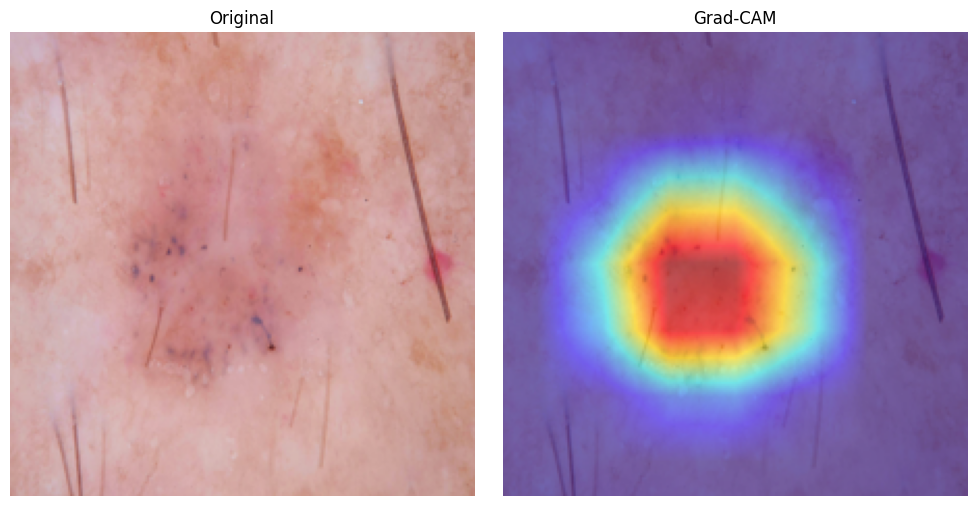

In [113]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.axis("off")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cam_image)
plt.axis("off")
plt.title("Grad-CAM")

plt.tight_layout()

plt.savefig(
    "gradcam_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

pred_class, conf = predict_fusion(
    image_path,
    metadata
)

print("Predicted class:", pred_class)
print(
    "Confidence:",
    round(conf * 100, 2),
    "%"
)

print(
    "Predictions are for research purposes only and should not be considered a medical diagnosis."
)


#### YOU CAN CHECK WHY WE DIDNOT APPLY HAIR REMOVEL TECHNIQUE , BECAUSE IT CREATED MORE NOISE BY HIDING REAL PATTERNS, TEXTURES, AND PIGMENTATIONS

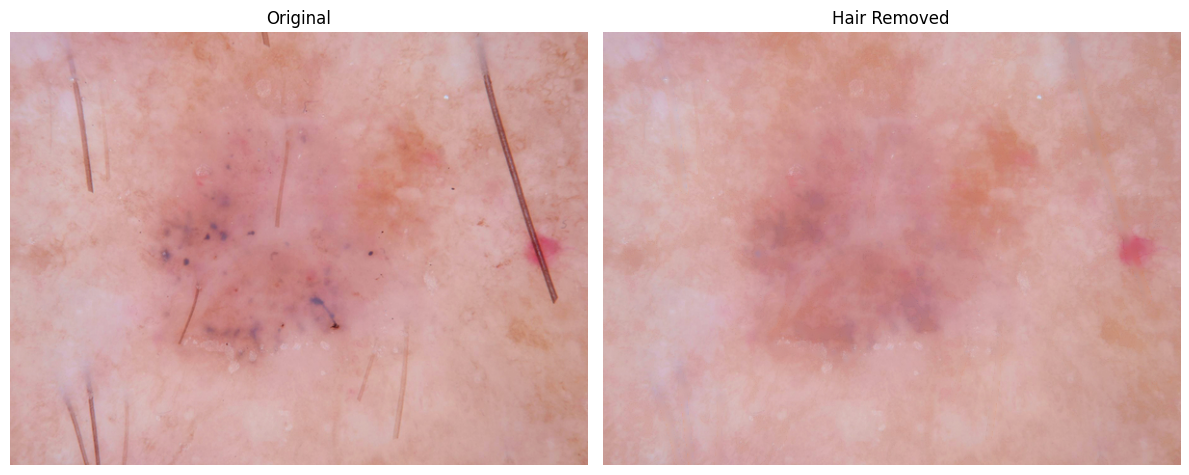

In [114]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_bgr = cv2.imread(image_path)

# Convert to RGB for display
img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

# Hair detection
gray = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2GRAY
)

kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (17,17)
)

blackhat = cv2.morphologyEx(
    gray,
    cv2.MORPH_BLACKHAT,
    kernel
)

_,hair_mask = cv2.threshold(
    blackhat,
    10,
    255,
    cv2.THRESH_BINARY
)

# Hair removal
hair_removed = cv2.inpaint(
    img_bgr,
    hair_mask,
    3,
    cv2.INPAINT_TELEA
)

hair_removed_rgb = cv2.cvtColor(
    hair_removed,
    cv2.COLOR_BGR2RGB
)

# Show comparison
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hair_removed_rgb)
plt.title("Hair Removed")
plt.axis("off")

plt.savefig(
    "hairemoval_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [332]:
cv2.imwrite("hair_removed_image.jpg",hair_removed) 

True

In [333]:
pred_class, conf = predict_fusion("hair_removed_image.jpg",metadata)
print("Predicted class:", pred_class)
print("Confidence:", round(conf*100,2), "%")

Predicted class: nv
Confidence: 65.71 %


# Hair Removal Preprocessing Analysis

## Objective

An additional experiment was conducted to evaluate whether hair-removal preprocessing could improve the performance of the proposed EfficientNetB0 Fusion model on dermoscopic images from the HAM10000 dataset.

Hair artifacts are commonly considered a source of visual noise in dermoscopy images. Therefore, a DullRazor-style preprocessing technique based on morphological filtering and image inpainting was applied to remove visible hairs before classification.

---

# Experimental Procedure

For each selected test image:

1. The original dermoscopic image was classified using the trained EfficientNetB0 Fusion model.
2. Hair removal was applied using morphological black-hat filtering and image inpainting.
3. The hair-removed image was reclassified using the same trained model.
4. Predictions and confidence scores were compared.

---

# Observed Results 

All original images were correctly classified but hair removal changed the lesion type.

## Case 1

### Original Image

Prediction: **mel (Melanoma)**

Confidence: **96.8%**

### Hair-Removed Image

Prediction: **bkl (Benign Keratosis-like Lesion)**

Confidence: **71.29%**

### Observation

The original image was classified with very high confidence as melanoma.

After hair removal, the prediction changed to a different lesion category and confidence dropped substantially.

---

## Case 2

### Original Image

Prediction: **mel (Melanoma)**

Confidence: **79.49%**

### Hair-Removed Image

Prediction: **bkl (Benign Keratosis-like Lesion)**

Confidence: **63.65%**

### Observation

Hair removal altered the lesion appearance and reduced the model's confidence.

The model produced an incorrect classification after preprocessing.

---

## Case 3

### Original Image

Prediction: **mel (Melanoma)**

Confidence: **79.03%**

### Hair-Removed Image

Prediction: **nv (Melanocytic Nevus)**

Confidence: **65.71%**

### Observation

Following hair removal, the prediction changed to a different lesion class and confidence decreased.

---

# Visual Analysis

Inspection of the Hair removal processed images revealed several undesirable effects:

* Loss of fine lesion texture.
* Blurring of lesion boundaries.
* Alteration of pigmentation patterns.
* Artificial smoothing introduced by image inpainting.
* Distortion of diagnostically relevant structures.

In images containing little or no hair, the preprocessing algorithm still modified lesion regions and surrounding skin texture.

As a result, the procedure occasionally introduced more visual distortion than the original hair artifacts themselves.

---

# Impact on Model Performance

Across the tested examples:

* Prediction confidence consistently decreased after hair removal.
* Several correctly classified lesions became misclassified.
* Diagnostic lesion patterns appeared less distinct.
* The model demonstrated greater reliability on original images than on preprocessed images.

These findings suggest that the trained CNN backbones had already learned to tolerate small hair artifacts present in HAM10000 images.

Removing hairs after training altered the image distribution and introduced a mismatch between training data and inference data.

---

# Conclusion

The hair-removal preprocessing experiment did not provide measurable benefits for the trained fusion models.

Instead, the preprocessing procedure frequently:

* Reduced prediction confidence.
* Introduced visual artifacts.
* Distorted lesion morphology.
* Increased misclassification rates.

Based on these observations, hair-removal preprocessing was not adopted in the final pipeline.

The final models achieved more reliable predictions when evaluated on the original dermoscopic images without additional hair-removal processing.

Therefore, for this study, preserving the original lesion appearance proved more beneficial than applying aggressive hair-removal preprocessing techniques.


### 🔴 Which ones are cancerous?

In [107]:
# using validation images for real prediction, these are the images which our model didnot see them
val_df.sample(10)

,image_id,sex_encoded,age_normalized,label,loc_abdomen,loc_acral,loc_back,loc_chest,loc_ear,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
51,ISIC_0028177,0,-0.405017,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1465,ISIC_0032127,1,1.072452,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
184,ISIC_0025539,1,1.367946,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1000,ISIC_0032953,0,-2.768967,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
746,ISIC_0031996,0,1.072452,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1032,ISIC_0030788,1,0.481464,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
925,ISIC_0028269,0,-0.405017,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
394,ISIC_0031987,0,-1.291498,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
597,ISIC_0024484,1,0.185971,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
588,ISIC_0024331,1,0.776958,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [239]:
class_names = ['akiec','bcc','bkl','df','mel','nv','vasc']
             #  [0,    ,1   ,  2,    3,   4 ,   5,     6  ]

In [240]:
print( "Class_counts",class_counts)

Class_counts dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64


In [241]:
val_df.shape

(1503, 19)

In [275]:
image_id= 'ISIC_0025987'

In [276]:
train_df

,image_id,sex_encoded,age_normalized,label,loc_abdomen,loc_acral,loc_back,loc_chest,loc_ear,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
0,ISIC_0028421,1,-0.405017,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,ISIC_0033598,0,-2.177979,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,ISIC_0028064,1,-1.882485,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,ISIC_0034284,1,-0.109523,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,ISIC_0033438,0,0.481464,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8507,ISIC_0032003,0,-1.291498,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
8508,ISIC_0029800,1,-0.996004,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8509,ISIC_0024563,0,-0.109523,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
8510,ISIC_0031491,1,0.776958,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [277]:
#check for leak data (validation images in training images)
image_id= "ISIC_0024392"
image_id in train_df['image_id'].values

False

In [278]:
# checking for common images
overlap = set(train_df['image_id']).intersection(set(val_df['image_id']))
len(overlap)

0

## ⚠️ Important Disclaimer

This notebook contains a comprehensive research workflow involving multiple experiments, architectural modifications, hyperparameter tuning strategies, feature engineering techniques, and fusion approaches conducted throughout the development process.

During experimentation, various models were trained and evaluated using different configurations, including image-only architectures, metadata-based models, simple fusion, attention fusion, and gated fusion mechanisms. As a result, the final notebook may contain code cells, utility functions, preprocessing pipelines, and training procedures that evolved over time.

Therefore, downloading or loading any saved model file (`.pth`, `.pkl`, or other serialized artifacts) does **not guarantee direct compatibility** with all code sections or user interface implementations present in this notebook. Some saved models may depend on specific preprocessing steps, architectural definitions, feature dimensions, metadata encodings, library versions, or experimental configurations that were active at the time of training.

Before using a saved model, users should verify:

* The exact model architecture used during training.
* Input image preprocessing and normalization settings.
* Metadata feature engineering and encoding procedures.
* Class label mappings.
* Required library and framework versions.
* Fusion strategy implementation (if applicable).

For reproducibility, it is recommended to review the corresponding training configuration and model definition before attempting inference, fine-tuning, deployment, or integration with external applications.

This notebook is intended primarily as a research and experimental framework rather than a production-ready deployment pipeline.
